<a href="https://colab.research.google.com/github/ShaojieDong503/HAD5016-Project-Phase-3/blob/main/Phase_3_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3 Modeling Notebook

This notebook loads the prepared Phase 3 datasets, tunes each model on a validation split derived from `train_val_df`, evaluates the selected model on `test_df`, and compares model performance.

Models included:
- Linear family
- Random Forest
- XGBoost
- Feedforward Neural Network
- LSTM


In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

!pip -q install xgboost tensorflow joblib


In [ ]:

import os
import json
import math
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


In [ ]:

# -----------------------------
# Paths
# -----------------------------
base_dir = "/content/drive/MyDrive/ML project data/Phase_3_data"
model_df_path = os.path.join(base_dir, "model_df.csv")
train_val_df_path = os.path.join(base_dir, "train_val_df.csv")
test_df_path = os.path.join(base_dir, "test_df.csv")

out_dir = os.path.join(base_dir, "model_comparison_outputs")
os.makedirs(out_dir, exist_ok=True)

print(model_df_path)
print(train_val_df_path)
print(test_df_path)
print(out_dir)


/content/drive/MyDrive/ML project data/Phase_3_data/model_df.csv
/content/drive/MyDrive/ML project data/Phase_3_data/train_val_df.csv
/content/drive/MyDrive/ML project data/Phase_3_data/test_df.csv
/content/drive/MyDrive/ML project data/Phase_3_data/model_comparison_outputs


In [ ]:

# -----------------------------
# Load prepared data
# -----------------------------
model_df = pd.read_csv(model_df_path)
train_val_df = pd.read_csv(train_val_df_path)
test_df = pd.read_csv(test_df_path)

print("model_df:", model_df.shape)
print("train_val_df:", train_val_df.shape)
print("test_df:", test_df.shape)

model_df.head()


model_df: (3884, 45)
train_val_df: (3299, 45)
test_df: (585, 45)


,naps_id,lat,lon,year,pm25,month,ym,acpcp_max,acpcp_mean,air_sfc_max,air_sfc_mean,albedo_max,albedo_mean,dswrf_max,dswrf_mean,evap_max,evap_mean,grid_id_5km,hcdc_max,hcdc_mean,hpbl_max,hpbl_mean,lcdc_max,lcdc_mean,mcdc_max,mcdc_mean,pr_wtr_max,pr_wtr_mean,pres_sfc_max,pres_sfc_mean,shum_2m_max,shum_2m_mean,uwnd_10m_max,uwnd_10m_mean,vis_max,vis_mean,vwnd_10m_max,vwnd_10m_mean,sat_est,ndvi,elev_m,orn_lat,orn_lon,road_weighted_km_per_km2,landcover
0,60104,45.43433,-75.67600,2010,4.537256,1,2010_01,0.015625,0.001323,273.03046,265.15780,52.8000,50.169353,133.03906,75.620964,0.191211,0.055363,99162,67.375,13.842742,1675.7795,708.08685,99.625,65.064514,82.25,28.161291,23.618689,7.234958,101316.14,100118.91,0.003737,0.002101,7.204187,2.028043,20005.354,8953.185,3.525551,-0.613268,0.2,0.01865,54.0,45.43433,-75.67600,57.228425,17.0
1,60106,45.38287,-75.71387,2010,3.851018,1,2010_01,0.015625,0.001323,273.03046,265.15780,52.8000,50.169353,133.03906,75.620964,0.191211,0.055363,98833,67.375,13.842742,1675.7795,708.08685,99.625,65.064514,82.25,28.161291,23.618689,7.234958,101316.14,100118.91,0.003737,0.002101,7.204187,2.028043,20005.354,8953.185,3.525551,-0.613268,0.2,-0.00605,79.0,45.38287,-75.71387,62.326946,17.0
2,60204,42.31578,-83.04367,2010,5.998656,1,2010_01,0.460938,0.016192,274.20267,268.79210,48.9375,34.972580,150.92969,95.856100,0.241753,0.067984,64629,85.875,13.149194,1492.9420,702.36430,98.000,52.629032,90.25,23.395160,18.430030,7.581732,100769.36,99520.11,0.004128,0.002465,7.171060,2.048268,20006.270,12133.831,3.887953,-0.039302,1.4,0.08210,182.0,42.31578,-83.04367,41.352139,17.0
3,60211,42.29289,-83.07314,2010,5.888961,1,2010_01,0.460938,0.016192,274.20267,268.79210,48.9375,34.972580,150.92969,95.856100,0.241753,0.067984,64301,85.875,13.149194,1492.9420,702.36430,98.000,52.629032,90.25,23.395160,18.430030,7.581732,100769.36,99520.11,0.004128,0.002465,7.171060,2.048268,20006.270,12133.831,3.887953,-0.039302,1.4,0.13490,177.0,42.29289,-83.07314,43.357353,18.0
4,60303,44.22008,-76.52141,2010,6.281884,1,2010_01,5.359375,0.316595,277.30910,273.18628,65.0000,21.225807,122.35156,81.158264,0.909586,0.213476,96836,66.125,13.072580,1938.1171,899.99580,100.000,69.201614,87.00,25.439516,26.431189,7.453204,101828.64,100576.97,0.004722,0.002745,7.125925,1.868234,20005.900,13325.765,4.567543,-0.337059,0.0,0.05270,93.0,44.22008,-76.52141,20.519202,17.0


In [ ]:

import numpy as np
import pandas as pd

def ym_to_date(ym_series):
    s = ym_series.astype(str).str.strip()
    s = s.str.replace(r"_(\d)$", r"_0\1", regex=True)
    return pd.to_datetime(s + "-01", format="%Y_%m-%d")

for df_name in ["model_df", "train_val_df", "test_df"]:
    df = globals()[df_name].copy()

    if "naps_id" not in df.columns:
        raise ValueError(f"{df_name} must contain 'naps_id' for LSTM.")

    if "date" not in df.columns:
        if "ym" in df.columns:
            df["date"] = ym_to_date(df["ym"])
        elif {"year", "month"}.issubset(df.columns):
            df["date"] = pd.to_datetime(
                df["year"].astype(int).astype(str) + "-" +
                df["month"].astype(int).astype(str).str.zfill(2) + "-01"
            )
        else:
            raise ValueError(f"{df_name} needs either 'date', 'ym', or year/month.")

    df["date"] = pd.to_datetime(df["date"])
    df["naps_id"] = df["naps_id"].astype(str).str.strip()
    globals()[df_name] = df

date_col = "date"
id_col = "naps_id"

print(train_val_df[[id_col, date_col]].head())
print(test_df[[id_col, date_col]].head())


  naps_id       date
0   60106 2010-01-01
1   60211 2010-01-01
2   60303 2010-01-01
3   60410 2010-01-01
4   60421 2010-01-01
  naps_id       date
0   60104 2010-01-01
1   60204 2010-01-01
2   60104 2011-01-01
3   60204 2011-01-01
4   60104 2012-01-01


In [ ]:

# -----------------------------
# Basic setup
# -----------------------------
candidate_targets = ["pm25", "PM25", "target", "y"]
target_col = next((c for c in candidate_targets if c in model_df.columns), None)
if target_col is None:
    raise ValueError(f"Could not find target column. Please set target_col manually. Columns: {model_df.columns.tolist()[:50]}")

id_col = "naps_id" if "naps_id" in model_df.columns else None
date_col = "date" if "date" in model_df.columns else None
year_col = "year" if "year" in model_df.columns else None
month_col = "month" if "month" in model_df.columns else None

for df in [model_df, train_val_df, test_df]:
    if date_col is not None and date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

exclude_cols = {target_col}
for c in [id_col, date_col, year_col, month_col, 'orn_lat', 'orn_lon', 'grid_id_5km', 'lat', 'lon']:
    if c is not None:
        exclude_cols.add(c)


feature_cols = [
    c for c in model_df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(model_df[c])
]

print("Target column:", target_col)
print("ID column:", id_col)
print("Date column:", date_col)
print("Number of features:", len(feature_cols))
print(feature_cols)


Target column: pm25
ID column: naps_id
Date column: date
Number of features: 35
['acpcp_max', 'acpcp_mean', 'air_sfc_max', 'air_sfc_mean', 'albedo_max', 'albedo_mean', 'dswrf_max', 'dswrf_mean', 'evap_max', 'evap_mean', 'hcdc_max', 'hcdc_mean', 'hpbl_max', 'hpbl_mean', 'lcdc_max', 'lcdc_mean', 'mcdc_max', 'mcdc_mean', 'pr_wtr_max', 'pr_wtr_mean', 'pres_sfc_max', 'pres_sfc_mean', 'shum_2m_max', 'shum_2m_mean', 'uwnd_10m_max', 'uwnd_10m_mean', 'vis_max', 'vis_mean', 'vwnd_10m_max', 'vwnd_10m_mean', 'sat_est', 'ndvi', 'elev_m', 'road_weighted_km_per_km2', 'landcover']


In [ ]:

# -----------------------------
# Validation split from train_val_df
# Prefer time-based split when date is available
# -----------------------------
def make_train_val_split(df, date_col="date", val_frac=0.2, seed=42):
    df = df.copy()

    if date_col is not None and date_col in df.columns and df[date_col].notna().any():
        unique_dates = np.array(sorted(df[date_col].dropna().unique()))
        n_val_dates = max(1, int(math.ceil(len(unique_dates) * val_frac)))
        val_dates = set(unique_dates[-n_val_dates:])

        train_df = df[~df[date_col].isin(val_dates)].copy()
        val_df = df[df[date_col].isin(val_dates)].copy()

        if len(train_df) > 0 and len(val_df) > 0:
            print(f"Used time-based validation split with {n_val_dates} held-out date groups")
            return train_df, val_df

    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_val = max(1, int(len(df) * val_frac))
    val_df = df.iloc[-n_val:].copy()
    train_df = df.iloc[:-n_val].copy()
    print("Used random validation split")
    return train_df, val_df

train_df, val_df = make_train_val_split(train_val_df, date_col=date_col, val_frac=0.2, seed=SEED)

print(train_df.shape, val_df.shape, test_df.shape)


Used time-based validation split with 32 held-out date groups
(2627, 46) (672, 46) (585, 46)


In [ ]:

# -----------------------------
# Shared helpers
# -----------------------------
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def r2(y_true, y_pred):
    return float(r2_score(y_true, y_pred))

def metric_row(model_name, split_name, y_true, y_pred):
    return {
        "model": model_name,
        "split": split_name,
        "rmse": rmse(y_true, y_pred),
        "mae": mae(y_true, y_pred),
        "r2": r2(y_true, y_pred),
        "n": int(len(y_true))
    }

def plot_prediction_scatter(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=12, alpha=0.5)
    mn = float(np.nanmin([np.nanmin(y_true), np.nanmin(y_pred)]))
    mx = float(np.nanmax([np.nanmax(y_true), np.nanmax(y_pred)]))
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(7, 4))
    plt.hist(residuals, bins=40)
    plt.xlabel("Residual (Observed - Predicted)")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()

def plot_metric_bars(df, metric, title):
    d = df.copy().sort_values(metric, ascending=(metric != "r2"))
    plt.figure(figsize=(10, 4))
    plt.bar(d["model"], d[metric])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel(metric.upper())
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [ ]:

# -----------------------------
# Tabular preprocessing
# -----------------------------
X_train_raw = train_df[feature_cols].copy()
y_train = train_df[target_col].values.astype("float32")

X_val_raw = val_df[feature_cols].copy()
y_val = val_df[target_col].values.astype("float32")

X_test_raw = test_df[feature_cols].copy()
y_test = test_df[target_col].values.astype("float32")

imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_raw)
X_val_imp = imputer.transform(X_val_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

joblib.dump(imputer, os.path.join(out_dir, "tabular_imputer.joblib"))
joblib.dump(scaler, os.path.join(out_dir, "tabular_scaler.joblib"))


['/content/drive/MyDrive/ML project data/Phase_3_data/model_comparison_outputs/tabular_scaler.joblib']

In [ ]:

# -----------------------------
# Results containers
# -----------------------------
validation_rows = []
test_rows = []
best_models = {}
model_predictions = {}


## Linear family

In [ ]:

linear_candidates = [
    ("linear_regression", LinearRegression()),
    ("ridge_0.1", Ridge(alpha=0.1, random_state=SEED)),
    ("ridge_1.0", Ridge(alpha=1.0, random_state=SEED)),
    ("ridge_10.0", Ridge(alpha=10.0, random_state=SEED)),
    ("lasso_0.001", Lasso(alpha=0.001, max_iter=5000, random_state=SEED)),
    ("lasso_0.01", Lasso(alpha=0.01, max_iter=5000, random_state=SEED)),
    ("elasticnet_0.001_0.5", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=SEED)),
    ("elasticnet_0.01_0.5", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000, random_state=SEED)),
]

linear_search_rows = []
best_linear_name = None
best_linear_model = None
best_linear_rmse = np.inf

for name, model in linear_candidates:
    model.fit(X_train_scaled, y_train)
    pred_val = model.predict(X_val_scaled)
    row = metric_row(name, "val", y_val, pred_val)
    validation_rows.append(row)
    linear_search_rows.append(row)
    if row["rmse"] < best_linear_rmse:
        best_linear_rmse = row["rmse"]
        best_linear_name = name
        best_linear_model = model

linear_search_df = pd.DataFrame(linear_search_rows).sort_values("rmse")
linear_search_df


,model,split,rmse,mae,r2,n
5,lasso_0.01,val,1.555640,1.234306,0.070554,672
7,elasticnet_0.01_0.5,val,1.561667,1.240818,0.063337,672
3,ridge_10.0,val,1.577006,1.255415,0.044848,672
4,lasso_0.001,val,1.580017,1.258574,0.041196,672
6,elasticnet_0.001_0.5,val,1.581150,1.259478,0.039820,672
2,ridge_1.0,val,1.584011,1.261829,0.036343,672
1,ridge_0.1,val,1.585089,1.262692,0.035031,672
0,linear_regression,val,1.585215,1.262791,0.034877,672


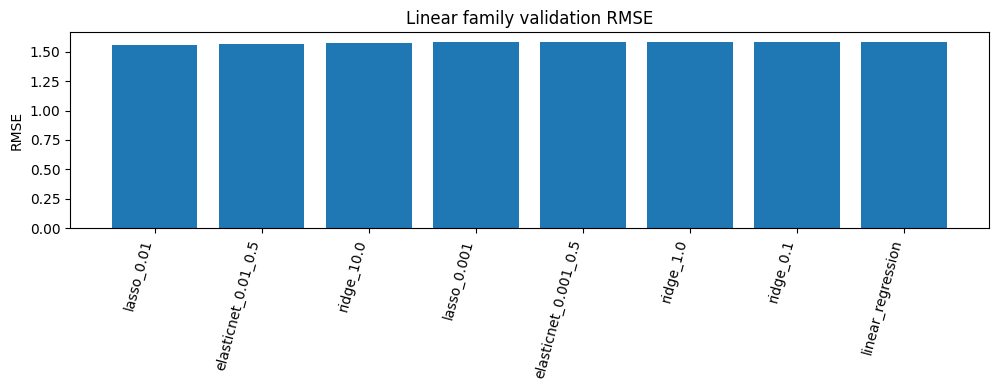

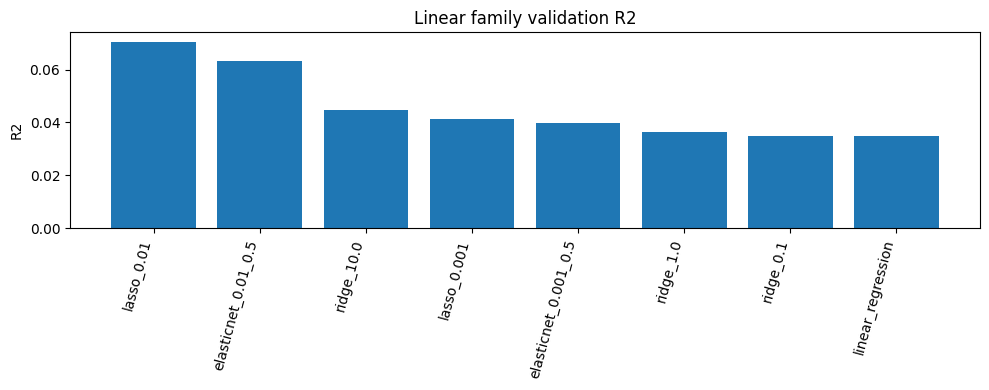

In [ ]:

plot_metric_bars(linear_search_df, "rmse", "Linear family validation RMSE")
plot_metric_bars(linear_search_df, "r2", "Linear family validation R2")


In [ ]:

y_pred_linear = best_linear_model.predict(X_test_scaled)
linear_test_row = metric_row("linear_family_best", "test", y_test, y_pred_linear)
test_rows.append(linear_test_row)
best_models["linear_family"] = best_linear_model
model_predictions["linear_family"] = y_pred_linear

pd.DataFrame([linear_test_row])


,model,split,rmse,mae,r2,n
0,linear_family_best,test,3.699179,2.086642,0.115752,585


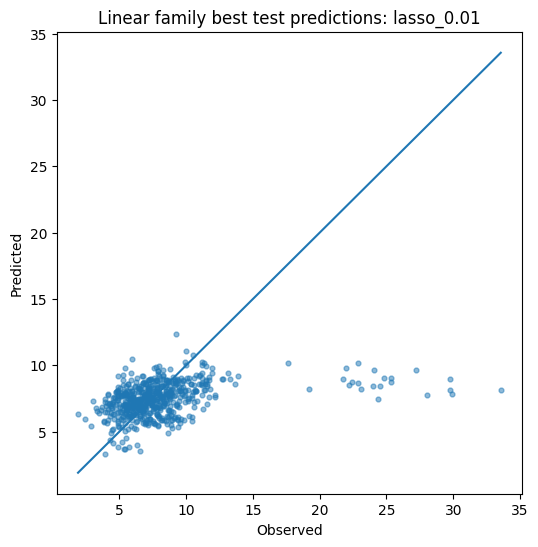

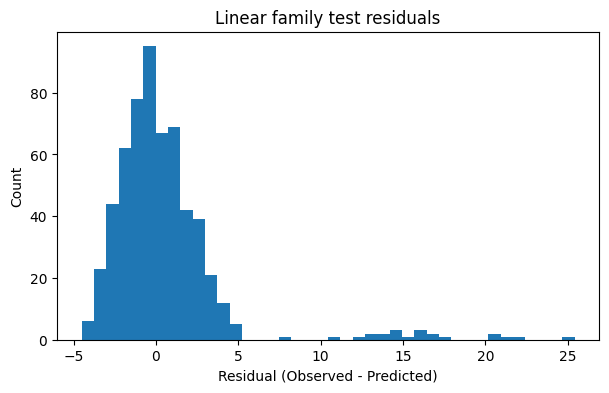

['/content/drive/MyDrive/ML project data/Phase_3_data/model_comparison_outputs/best_linear_family.joblib']

In [ ]:

plot_prediction_scatter(y_test, y_pred_linear, f"Linear family best test predictions: {best_linear_name}")
plot_residuals(y_test, y_pred_linear, "Linear family test residuals")

joblib.dump(best_linear_model, os.path.join(out_dir, "best_linear_family.joblib"))


## Random Forest

In [ ]:

rf_grid = [
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 20, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 12, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 3, "max_features": 0.5},
]

rf_search_rows = []
best_rf_model = None
best_rf_params = None
best_rf_rmse = np.inf

for params in rf_grid:
    model = RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
    model.fit(X_train_imp, y_train)
    pred_val = model.predict(X_val_imp)
    row = metric_row(f"rf_{params}", "val", y_val, pred_val)
    validation_rows.append(row)
    rf_search_rows.append(row)
    if row["rmse"] < best_rf_rmse:
        best_rf_rmse = row["rmse"]
        best_rf_model = model
        best_rf_params = params

rf_search_df = pd.DataFrame(rf_search_rows).sort_values("rmse")
rf_search_df


,model,split,rmse,mae,r2,n
1,"rf_{'n_estimators': 400, 'max_depth': None, 'm...",val,1.388400,1.077731,0.259653,672
0,"rf_{'n_estimators': 200, 'max_depth': None, 'm...",val,1.398132,1.085134,0.249238,672
2,"rf_{'n_estimators': 300, 'max_depth': 20, 'min...",val,1.400770,1.088326,0.246402,672
4,"rf_{'n_estimators': 300, 'max_depth': None, 'm...",val,1.419168,1.106443,0.226476,672
3,"rf_{'n_estimators': 300, 'max_depth': 12, 'min...",val,1.420981,1.111191,0.224498,672


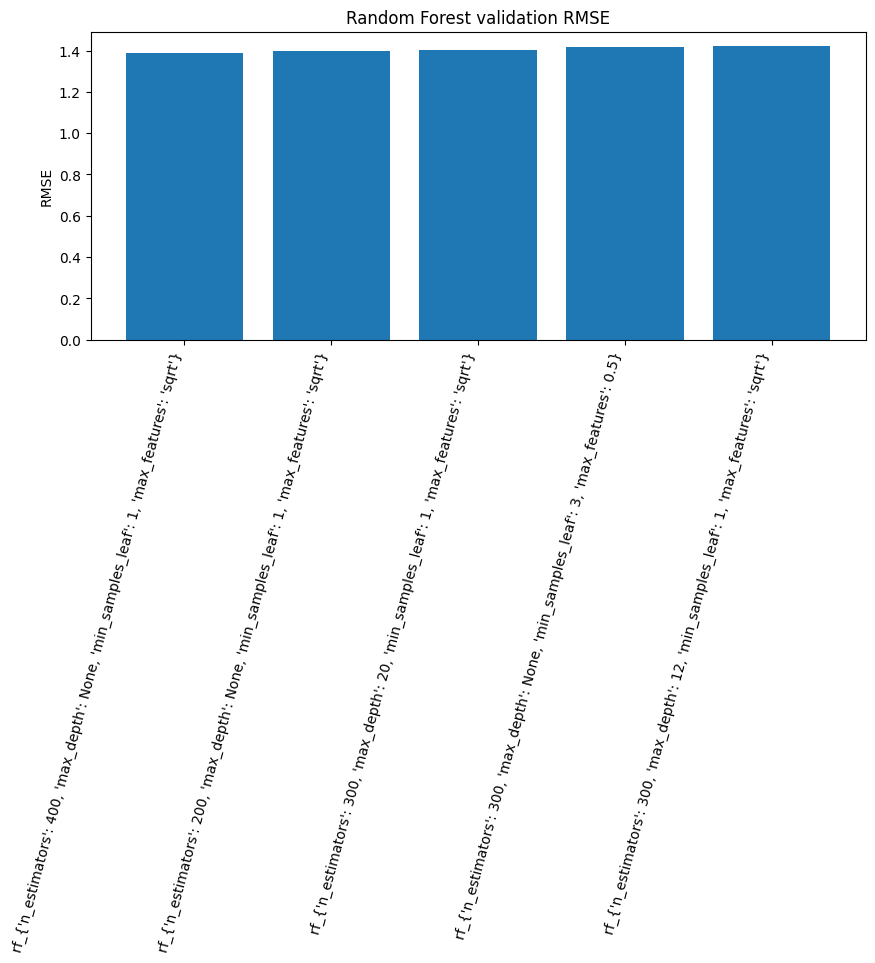

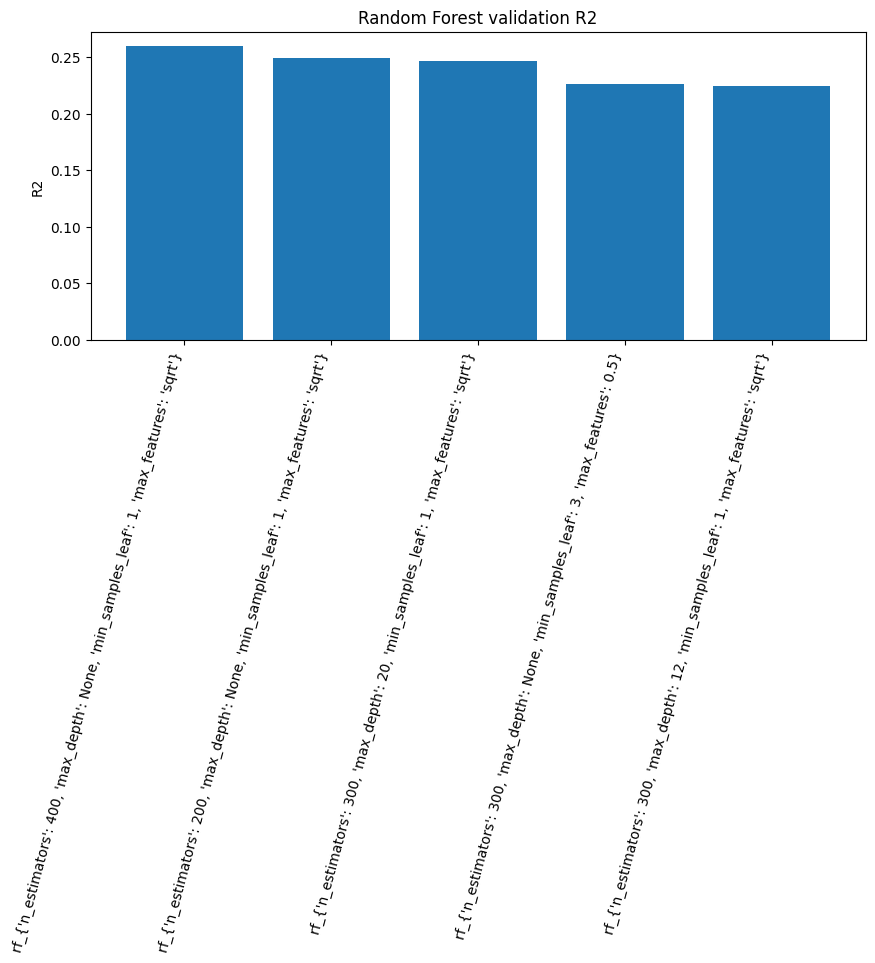

In [ ]:

plot_metric_bars(rf_search_df, "rmse", "Random Forest validation RMSE")
plot_metric_bars(rf_search_df, "r2", "Random Forest validation R2")


In [ ]:

y_pred_rf = best_rf_model.predict(X_test_imp)
rf_test_row = metric_row("random_forest_best", "test", y_test, y_pred_rf)
test_rows.append(rf_test_row)
best_models["random_forest"] = best_rf_model
model_predictions["random_forest"] = y_pred_rf

pd.DataFrame([rf_test_row])


,model,split,rmse,mae,r2,n
0,random_forest_best,test,3.665737,1.584041,0.131668,585


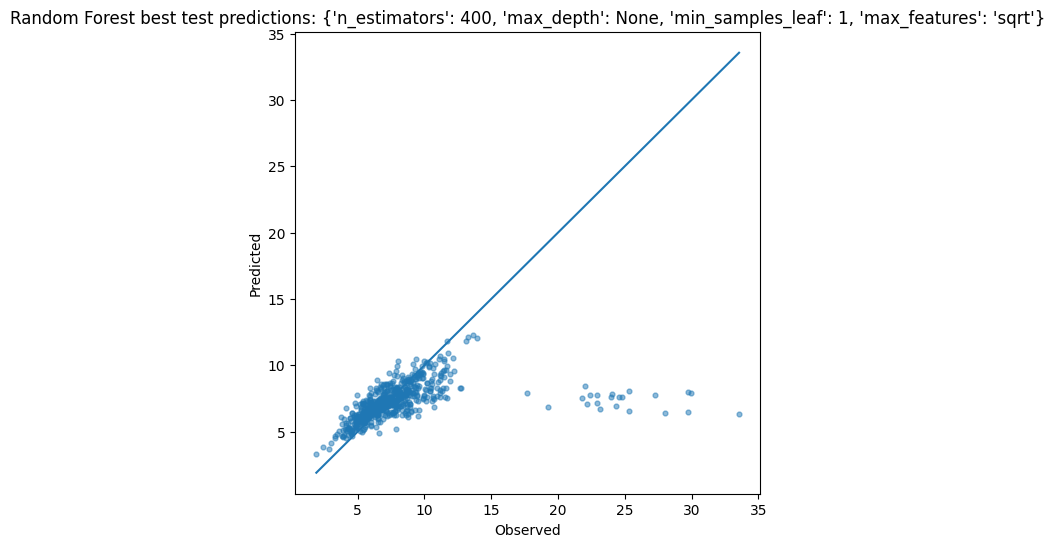

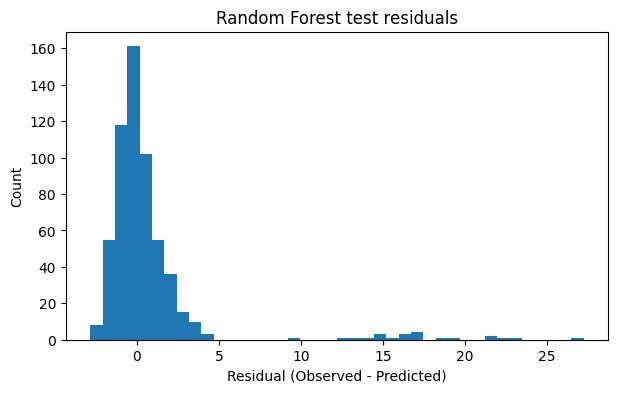

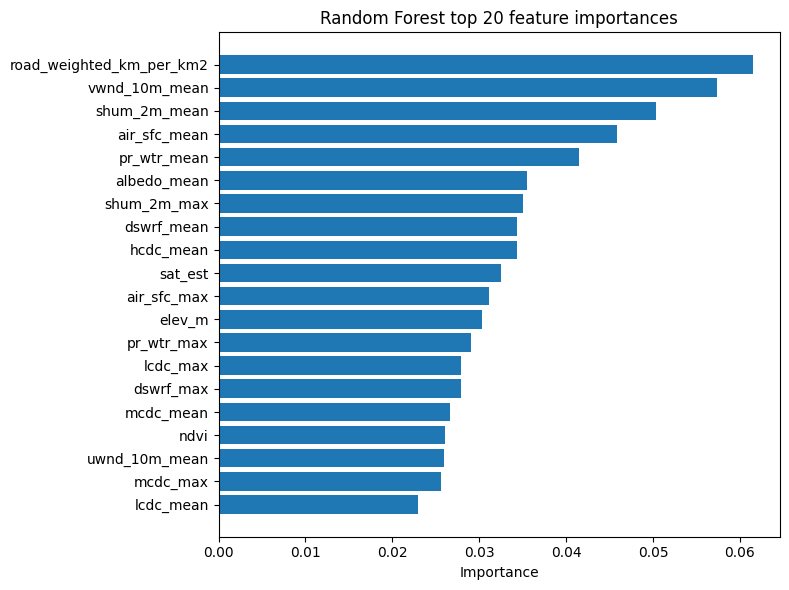

['/content/drive/MyDrive/ML project data/Phase_3_data/model_comparison_outputs/best_random_forest.joblib']

In [ ]:

plot_prediction_scatter(y_test, y_pred_rf, f"Random Forest best test predictions: {best_rf_params}")
plot_residuals(y_test, y_pred_rf, "Random Forest test residuals")

rf_importance = pd.Series(best_rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
plt.barh(rf_importance.index[::-1], rf_importance.values[::-1])
plt.title("Random Forest top 20 feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

joblib.dump(best_rf_model, os.path.join(out_dir, "best_random_forest.joblib"))


## XGBoost

In [ ]:

xgb_grid = [
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 4, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 500, "learning_rate": 0.05, "max_depth": 6, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 700, "learning_rate": 0.03, "max_depth": 6, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 8, "subsample": 0.8, "colsample_bytree": 0.8},
]

xgb_search_rows = []
xgb_evals = {}
best_xgb_model = None
best_xgb_params = None
best_xgb_rmse = np.inf
best_xgb_name = None

for idx, params in enumerate(xgb_grid, start=1):
    name = f"xgb_{idx}"
    model = XGBRegressor(
        **params,
        objective="reg:squarederror",
        random_state=SEED,
        tree_method="hist",
        eval_metric="rmse",
        n_jobs=-1,
        early_stopping_rounds=30,
    )
    model.fit(
        X_train_imp, y_train,
        eval_set=[(X_train_imp, y_train), (X_val_imp, y_val)],
        verbose=False,
    )
    pred_val = model.predict(X_val_imp)
    row = metric_row(f"{name}_{params}", "val", y_val, pred_val)
    validation_rows.append(row)
    xgb_search_rows.append(row)
    xgb_evals[name] = model.evals_result()
    if row["rmse"] < best_xgb_rmse:
        best_xgb_rmse = row["rmse"]
        best_xgb_model = model
        best_xgb_params = params
        best_xgb_name = name

xgb_search_df = pd.DataFrame(xgb_search_rows).sort_values("rmse")
xgb_search_df


,model,split,rmse,mae,r2,n
3,"xgb_4_{'n_estimators': 500, 'learning_rate': 0...",val,1.389484,1.087618,0.258496,672
2,"xgb_3_{'n_estimators': 700, 'learning_rate': 0...",val,1.394507,1.102188,0.253125,672
0,"xgb_1_{'n_estimators': 300, 'learning_rate': 0...",val,1.400214,1.118482,0.247000,672
1,"xgb_2_{'n_estimators': 500, 'learning_rate': 0...",val,1.410474,1.109357,0.235925,672


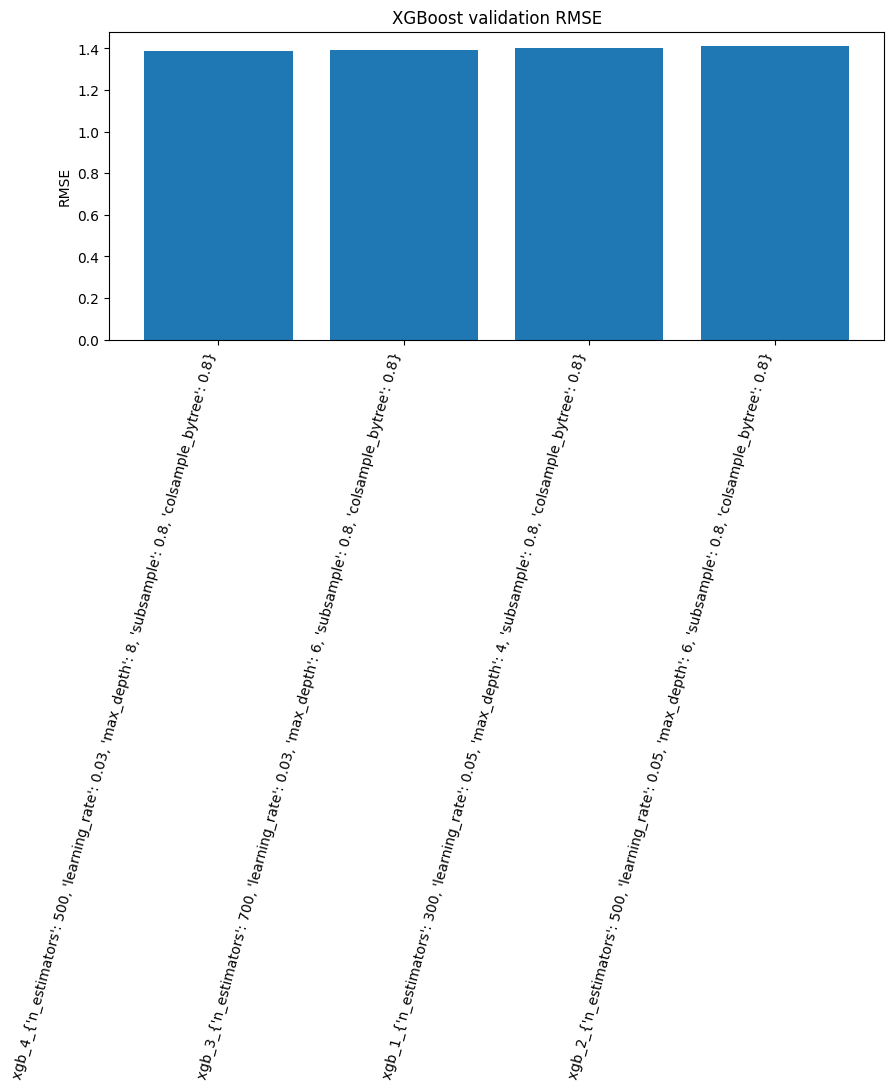

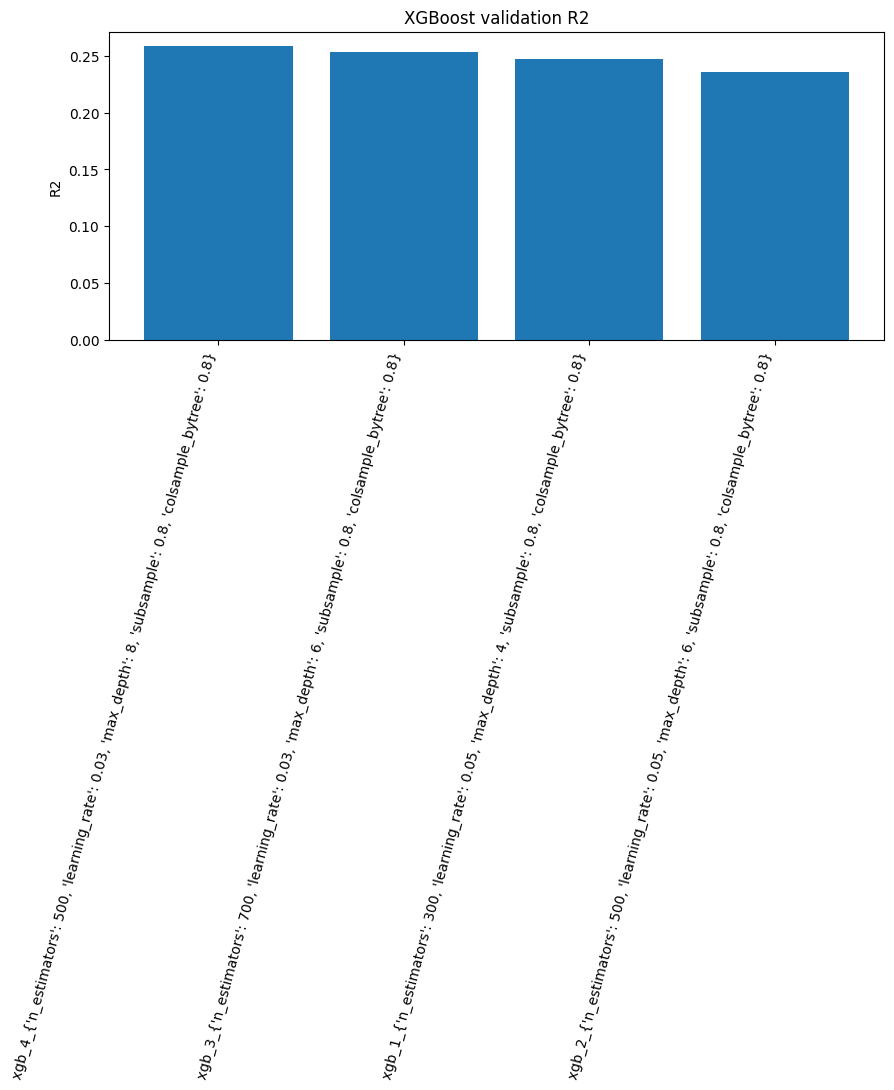

In [ ]:

plot_metric_bars(xgb_search_df, "rmse", "XGBoost validation RMSE")
plot_metric_bars(xgb_search_df, "r2", "XGBoost validation R2")


In [ ]:

y_pred_xgb = best_xgb_model.predict(X_test_imp)
xgb_test_row = metric_row("xgboost_best", "test", y_test, y_pred_xgb)
test_rows.append(xgb_test_row)
best_models["xgboost"] = best_xgb_model
model_predictions["xgboost"] = y_pred_xgb

pd.DataFrame([xgb_test_row])


,model,split,rmse,mae,r2,n
0,xgboost_best,test,3.83996,1.945341,0.047167,585


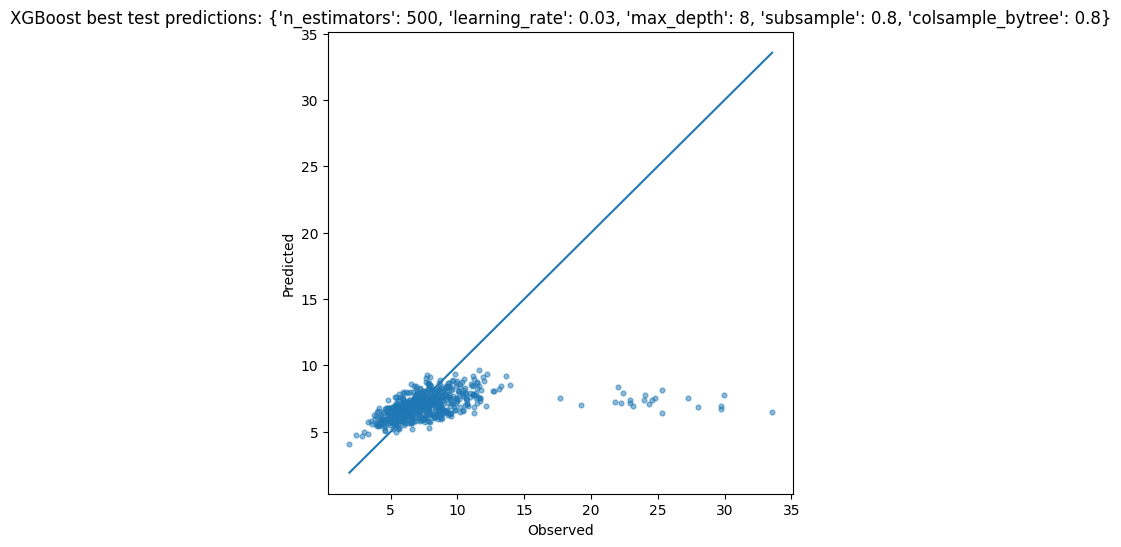

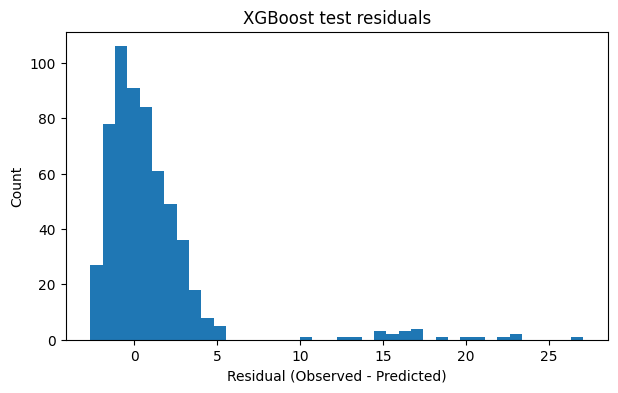

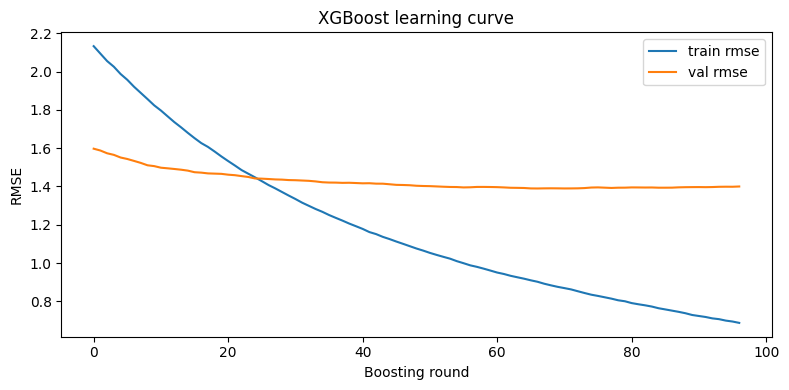

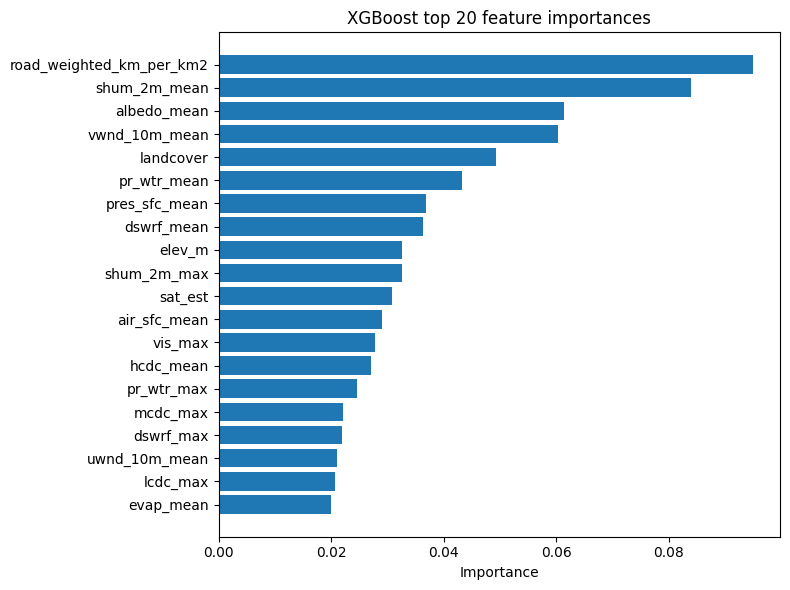

['/content/drive/MyDrive/ML project data/Phase_3_data/model_comparison_outputs/best_xgboost.joblib']

In [ ]:

plot_prediction_scatter(y_test, y_pred_xgb, f"XGBoost best test predictions: {best_xgb_params}")
plot_residuals(y_test, y_pred_xgb, "XGBoost test residuals")

best_eval = xgb_evals[best_xgb_name]
train_curve = best_eval["validation_0"]["rmse"]
val_curve = best_eval["validation_1"]["rmse"]

plt.figure(figsize=(8, 4))
plt.plot(train_curve, label="train rmse")
plt.plot(val_curve, label="val rmse")
plt.xlabel("Boosting round")
plt.ylabel("RMSE")
plt.title("XGBoost learning curve")
plt.legend()
plt.tight_layout()
plt.show()

xgb_importance = pd.Series(best_xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
plt.barh(xgb_importance.index[::-1], xgb_importance.values[::-1])
plt.title("XGBoost top 20 feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

joblib.dump(best_xgb_model, os.path.join(out_dir, "best_xgboost.joblib"))


## Feedforward Neural Network

In [ ]:

def make_ffnn(input_dim, hidden_units=(128, 64), dropout=0.0, lr=0.001):
    model = Sequential([Input(shape=(input_dim,))])
    for units in hidden_units:
        model.add(Dense(units, activation="relu"))
        if dropout > 0:
            model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss="mse", metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")])
    return model

ffnn_grid = [
    {"hidden_units": (128, 64), "dropout": 0.0, "lr": 0.001, "batch_size": 256},
    {"hidden_units": (256, 128), "dropout": 0.0, "lr": 0.001, "batch_size": 256},
    {"hidden_units": (128, 64, 32), "dropout": 0.1, "lr": 0.001, "batch_size": 256},
    {"hidden_units": (128, 64), "dropout": 0.2, "lr": 0.0005, "batch_size": 256},
]

ffnn_search_rows = []
ffnn_histories = {}
best_ffnn_model = None
best_ffnn_params = None
best_ffnn_rmse = np.inf
best_ffnn_name = None

for idx, params in enumerate(ffnn_grid, start=1):
    name = f"ffnn_{idx}"
    model = make_ffnn(input_dim=X_train_scaled.shape[1], hidden_units=params["hidden_units"], dropout=params["dropout"], lr=params["lr"])
    es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=params["batch_size"],
        verbose=0,
        callbacks=[es],
    )
    pred_val = model.predict(X_val_scaled, verbose=0).flatten()
    row = metric_row(f"{name}_{params}", "val", y_val, pred_val)
    validation_rows.append(row)
    ffnn_search_rows.append(row)
    ffnn_histories[name] = history.history
    if row["rmse"] < best_ffnn_rmse:
        best_ffnn_rmse = row["rmse"]
        best_ffnn_model = model
        best_ffnn_params = params
        best_ffnn_name = name

ffnn_search_df = pd.DataFrame(ffnn_search_rows).sort_values("rmse")
ffnn_search_df


,model,split,rmse,mae,r2,n
2,"ffnn_3_{'hidden_units': (128, 64, 32), 'dropou...",val,1.574067,1.217376,0.048405,672
3,"ffnn_4_{'hidden_units': (128, 64), 'dropout': ...",val,1.617561,1.267502,-0.004911,672
1,"ffnn_2_{'hidden_units': (256, 128), 'dropout':...",val,1.665486,1.304277,-0.065340,672
0,"ffnn_1_{'hidden_units': (128, 64), 'dropout': ...",val,1.701337,1.326251,-0.111698,672


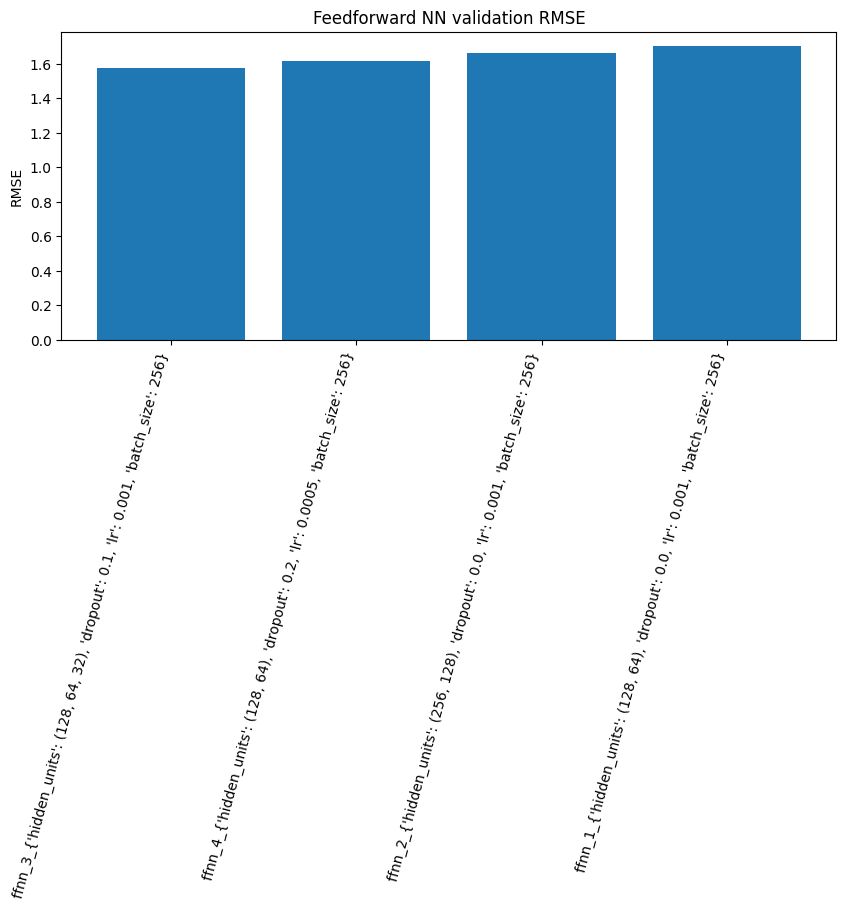

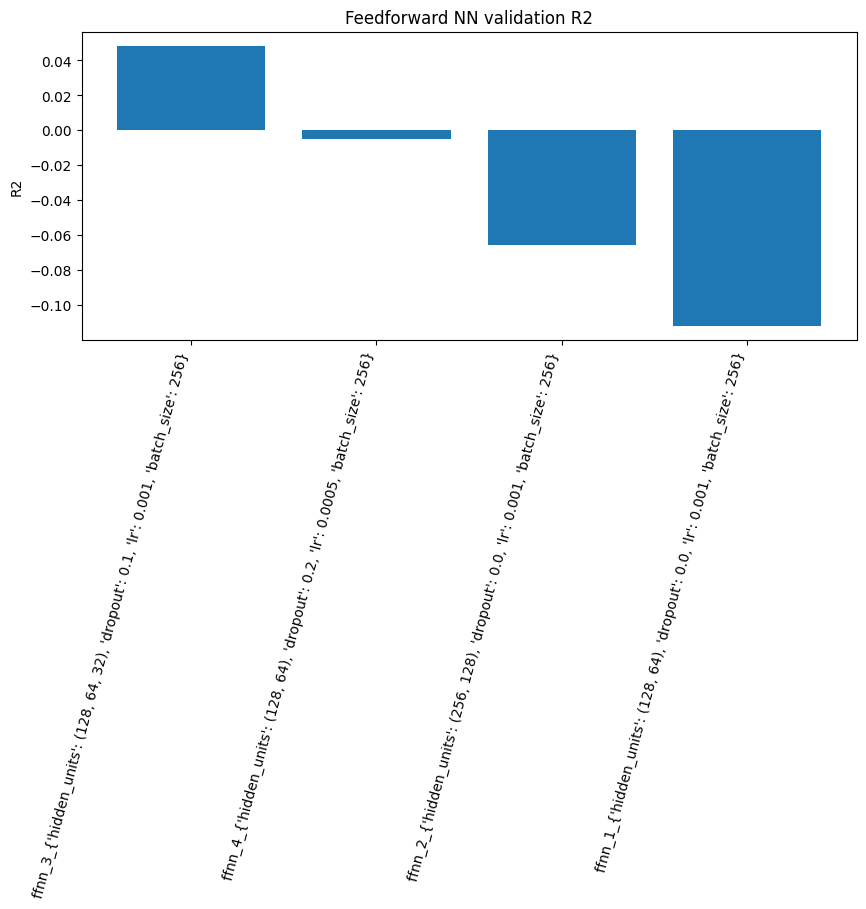

In [ ]:

plot_metric_bars(ffnn_search_df, "rmse", "Feedforward NN validation RMSE")
plot_metric_bars(ffnn_search_df, "r2", "Feedforward NN validation R2")


In [ ]:

y_pred_ffnn = best_ffnn_model.predict(X_test_scaled, verbose=0).flatten()
ffnn_test_row = metric_row("ffnn_best", "test", y_test, y_pred_ffnn)
test_rows.append(ffnn_test_row)
best_models["ffnn"] = best_ffnn_model
model_predictions["ffnn"] = y_pred_ffnn

pd.DataFrame([ffnn_test_row])


,model,split,rmse,mae,r2,n
0,ffnn_best,test,3.662073,1.985392,0.133403,585


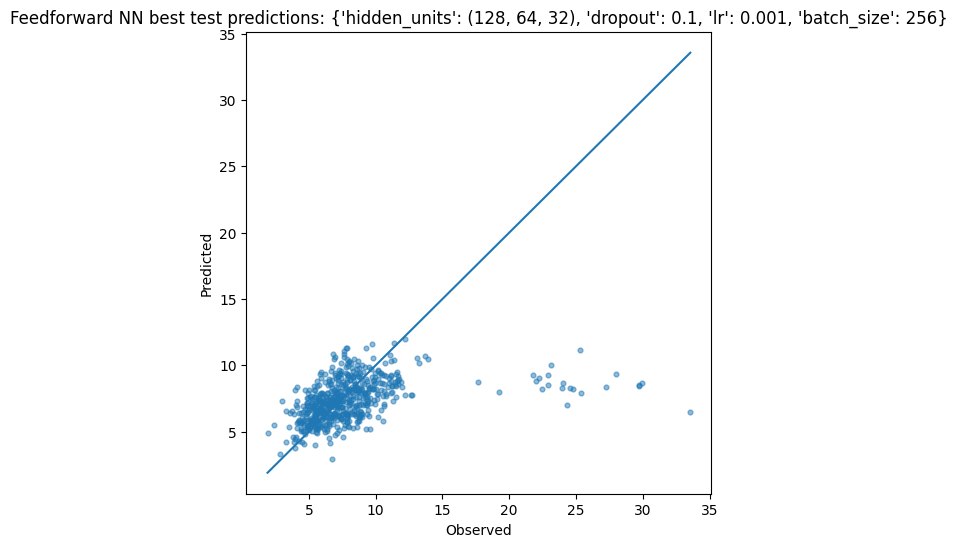

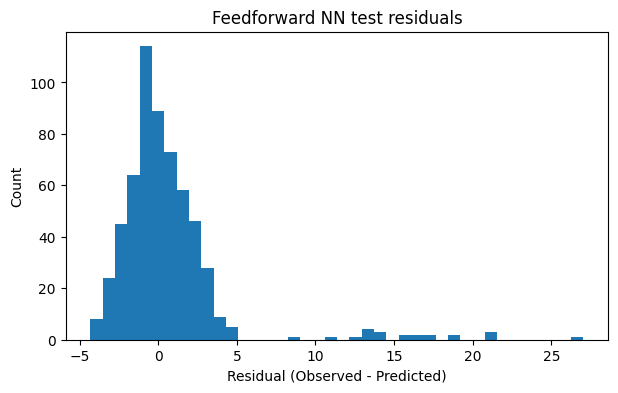

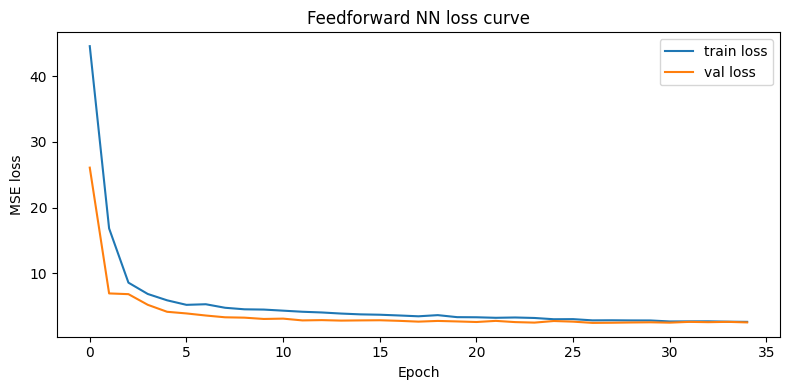

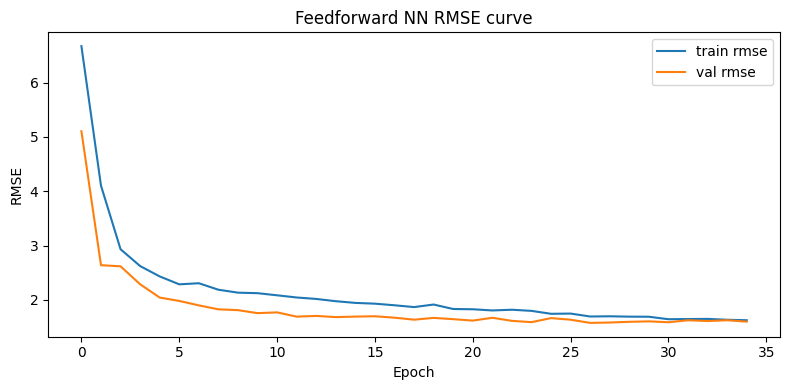

In [ ]:

plot_prediction_scatter(y_test, y_pred_ffnn, f"Feedforward NN best test predictions: {best_ffnn_params}")
plot_residuals(y_test, y_pred_ffnn, "Feedforward NN test residuals")

hist = ffnn_histories[best_ffnn_name]
plt.figure(figsize=(8, 4))
plt.plot(hist["loss"], label="train loss")
plt.plot(hist["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Feedforward NN loss curve")
plt.legend()
plt.tight_layout()
plt.show()

if "rmse" in hist and "val_rmse" in hist:
    plt.figure(figsize=(8, 4))
    plt.plot(hist["rmse"], label="train rmse")
    plt.plot(hist["val_rmse"], label="val rmse")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.title("Feedforward NN RMSE curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

best_ffnn_model.save(os.path.join(out_dir, "best_ffnn.keras"))


## LSTM

In [ ]:

counts = train_val_df.groupby("naps_id").size()
print(counts.describe())

print("\nSmallest histories:")
print(counts.sort_values().head(10))

print("\nLargest histories:")
print(counts.sort_values(ascending=False).head(10))


count     32.000000
mean     103.093750
std       54.747137
min        1.000000
25%       57.000000
50%      110.000000
75%      156.000000
max      156.000000
dtype: float64

Smallest histories:
naps_id
60429     1
60439     3
60413     9
61501    12
60903    35
60445    43
60303    48
60521    48
61703    60
60440    72
dtype: int64

Largest histories:
naps_id
60211    156
60410    156
60435    156
60430    156
60512    156
61502    156
61104    156
60809    156
65401    156
61402    156
dtype: int64


In [ ]:

for df_name in ["model_df", "train_val_df", "test_df"]:
    df = globals()[df_name].copy()
    df = df.sort_values(["naps_id", "date"])

    df["pm25_lag1"] = df.groupby("naps_id")[target_col].shift(1)
    df["pm25_lag2"] = df.groupby("naps_id")[target_col].shift(2)
    df["pm25_lag3"] = df.groupby("naps_id")[target_col].shift(3)

    globals()[df_name] = df

print(train_val_df[["naps_id", "date", target_col, "pm25_lag1", "pm25_lag2", "pm25_lag3"]].head(12))


     naps_id       date      pm25  pm25_lag1  pm25_lag2  pm25_lag3
0      60106 2010-01-01  3.851018        NaN        NaN        NaN
274    60106 2010-02-01  2.001488   3.851018        NaN        NaN
548    60106 2010-03-01  3.123289   2.001488   3.851018        NaN
822    60106 2010-04-01  3.758696   3.123289   2.001488   3.851018
1098   60106 2010-05-01  5.956208   3.758696   3.123289   2.001488
1373   60106 2010-06-01  5.101800   5.956208   3.758696   3.123289
1649   60106 2010-07-01  8.118168   5.101800   5.956208   3.758696
1924   60106 2010-08-01  6.581989   8.118168   5.101800   5.956208
2199   60106 2010-09-01  3.671629   6.581989   8.118168   5.101800
2474   60106 2010-10-01  2.642898   3.671629   6.581989   8.118168
2749   60106 2010-11-01  3.712500   2.642898   3.671629   6.581989
3023   60106 2010-12-01  3.073983   3.712500   2.642898   3.671629


In [ ]:

exclude_cols_lstm = {
    "naps_id", "date", "ym", "year", "month", target_col, "lat", "lon", 'x_3347_left_mean',
          'x_3347_left_max', 'x_3347_right_mean', 'x_3347_right_max', 'y_3347_left_mean',
          'y_3347_left_max', 'y_3347_right_mean', 'y_3347_right_max', 'orn_lat', 'orn_lon', 'grid_id_5km_mean', 'grid_id_5km_max', 'grid_id_5km'
}

feature_cols_lstm = [
    c for c in model_df.columns
    if c not in exclude_cols_lstm and pd.api.types.is_numeric_dtype(model_df[c])
]

print("Number of LSTM features:", len(feature_cols_lstm))
print(feature_cols_lstm[:30])


Number of LSTM features: 38
['acpcp_max', 'acpcp_mean', 'air_sfc_max', 'air_sfc_mean', 'albedo_max', 'albedo_mean', 'dswrf_max', 'dswrf_mean', 'evap_max', 'evap_mean', 'hcdc_max', 'hcdc_mean', 'hpbl_max', 'hpbl_mean', 'lcdc_max', 'lcdc_mean', 'mcdc_max', 'mcdc_mean', 'pr_wtr_max', 'pr_wtr_mean', 'pres_sfc_max', 'pres_sfc_mean', 'shum_2m_max', 'shum_2m_mean', 'uwnd_10m_max', 'uwnd_10m_mean', 'vis_max', 'vis_mean', 'vwnd_10m_max', 'vwnd_10m_mean']


In [ ]:

def make_time_based_train_val_split(df, date_col="date", val_frac=0.2):
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col])

    unique_dates = np.array(sorted(d[date_col].dropna().unique()))
    n_val_dates = max(1, int(np.ceil(len(unique_dates) * val_frac)))
    val_dates = set(unique_dates[-n_val_dates:])

    train_df = d[~d[date_col].isin(val_dates)].copy()
    val_df = d[d[date_col].isin(val_dates)].copy()

    return train_df, val_df

train_df_lstm, val_df_lstm = make_time_based_train_val_split(train_val_df, date_col="date", val_frac=0.2)
test_df_lstm = test_df.copy()

print("train_df_lstm:", train_df_lstm.shape)
print("val_df_lstm:", val_df_lstm.shape)
print("test_df_lstm:", test_df_lstm.shape)


train_df_lstm: (2627, 49)
val_df_lstm: (672, 49)
test_df_lstm: (585, 49)


In [ ]:

def fit_sequence_imputer_and_scaler(train_df, feature_cols):
    imp = SimpleImputer(strategy="median")
    scl = StandardScaler()

    arr = imp.fit_transform(train_df[feature_cols])
    scl.fit(arr)

    return imp, scl

def apply_sequence_imputer_and_scaler(df, feature_cols, imp, scl):
    out = df.copy()
    arr = imp.transform(out[feature_cols])
    arr = scl.transform(arr)
    out[feature_cols] = arr
    return out

seq_imputer, seq_scaler = fit_sequence_imputer_and_scaler(train_df_lstm, feature_cols_lstm)

train_seq_df = apply_sequence_imputer_and_scaler(train_df_lstm, feature_cols_lstm, seq_imputer, seq_scaler)
val_seq_df = apply_sequence_imputer_and_scaler(val_df_lstm, feature_cols_lstm, seq_imputer, seq_scaler)
test_seq_df = apply_sequence_imputer_and_scaler(test_df_lstm, feature_cols_lstm, seq_imputer, seq_scaler)

print(train_seq_df[["naps_id", "date"]].head())


     naps_id       date
0      60106 2010-01-01
274    60106 2010-02-01
548    60106 2010-03-01
822    60106 2010-04-01
1098   60106 2010-05-01


In [ ]:

def build_lstm_sequences(df, feature_cols, target_col, id_col="naps_id", date_col="date", seq_len=12):
    if id_col not in df.columns or date_col not in df.columns:
        raise ValueError(f"LSTM requires both '{id_col}' and '{date_col}'.")

    d = df.copy()
    d[id_col] = d[id_col].astype(str).str.strip()
    d[date_col] = pd.to_datetime(d[date_col])
    d = d.sort_values([id_col, date_col])

    X_list = []
    y_list = []
    meta_rows = []

    for sid, sub in d.groupby(id_col):
        sub = sub.sort_values(date_col).copy()
        sub = sub.dropna(subset=[target_col])

        if len(sub) <= seq_len:
            continue

        X_vals = sub[feature_cols].values.astype("float32")
        y_vals = sub[target_col].values.astype("float32")
        date_vals = sub[date_col].values

        for i in range(len(sub) - seq_len):
            X_list.append(X_vals[i:i + seq_len])
            y_list.append(y_vals[i + seq_len])
            meta_rows.append({
                id_col: sid,
                date_col: date_vals[i + seq_len]
            })

    if len(X_list) == 0:
        return (
            np.empty((0, seq_len, len(feature_cols)), dtype="float32"),
            np.array([], dtype="float32"),
            pd.DataFrame(meta_rows)
        )

    return (
        np.array(X_list, dtype="float32"),
        np.array(y_list, dtype="float32"),
        pd.DataFrame(meta_rows)
    )


In [ ]:

seq_len = 12

X_train_seq, y_train_seq, meta_train_seq = build_lstm_sequences(
    train_seq_df,
    feature_cols_lstm,
    target_col,
    id_col="naps_id",
    date_col="date",
    seq_len=seq_len
)

X_val_seq, y_val_seq, meta_val_seq = build_lstm_sequences(
    val_seq_df,
    feature_cols_lstm,
    target_col,
    id_col="naps_id",
    date_col="date",
    seq_len=seq_len
)

X_test_seq, y_test_seq, meta_test_seq = build_lstm_sequences(
    test_seq_df,
    feature_cols_lstm,
    target_col,
    id_col="naps_id",
    date_col="date",
    seq_len=seq_len
)

print("X_train_seq:", X_train_seq.shape)
print("X_val_seq:", X_val_seq.shape)
print("X_test_seq:", X_test_seq.shape)
if X_train_seq.shape[0] == 0 or X_val_seq.shape[0] == 0:
    print("No usable sequences with seq_len=12. Change seq_len to 6 and rerun from this cell.")


X_train_seq: (2267, 12, 38)
X_val_seq: (420, 12, 38)
X_test_seq: (312, 12, 38)


In [ ]:

def make_lstm_model(input_timesteps, input_dim, units=64, dense_units=32, dropout=0.2, lr=0.001):
    model = Sequential([
        Input(shape=(input_timesteps, input_dim)),
        LSTM(units),
        Dropout(dropout),
        Dense(dense_units, activation="relu"),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")]
    )
    return model

lstm_grid = [
    {"units": 32, "dense_units": 16, "dropout": 0.0, "lr": 0.001, "batch_size": 128},
    {"units": 64, "dense_units": 32, "dropout": 0.0, "lr": 0.001, "batch_size": 128},
    {"units": 64, "dense_units": 32, "dropout": 0.2, "lr": 0.001, "batch_size": 128},
]

lstm_results = []
lstm_histories = {}
best_lstm_model = None
best_lstm_history = None
best_lstm_cfg = None
best_val_rmse = np.inf
best_lstm_name = None

if X_train_seq.shape[0] == 0 or X_val_seq.shape[0] == 0:
    print("Skipping LSTM training because no usable sequences were created.")
else:
    for i, cfg in enumerate(lstm_grid, start=1):
        print(f"\nTraining LSTM config {i}/{len(lstm_grid)}: {cfg}")

        model = make_lstm_model(
            input_timesteps=seq_len,
            input_dim=len(feature_cols_lstm),
            units=cfg["units"],
            dense_units=cfg["dense_units"],
            dropout=cfg["dropout"],
            lr=cfg["lr"]
        )

        es = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        history = model.fit(
            X_train_seq,
            y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=50,
            batch_size=cfg["batch_size"],
            verbose=0,
            callbacks=[es]
        )

        val_pred = model.predict(X_val_seq, verbose=0).flatten()
        result = {
            "model": f"lstm_{i}",
            "split": "val",
            "rmse": rmse(y_val_seq, val_pred),
            "mae": mae(y_val_seq, val_pred),
            "r2": r2(y_val_seq, val_pred),
            "units": cfg["units"],
            "dense_units": cfg["dense_units"],
            "dropout": cfg["dropout"],
            "lr": cfg["lr"],
            "batch_size": cfg["batch_size"],
            "seq_len": seq_len,
            "epochs_run": len(history.history["loss"])
        }
        lstm_results.append(result)
        validation_rows.append(result)
        lstm_histories[f"lstm_{i}"] = history.history
        print(result)

        if result["rmse"] < best_val_rmse:
            best_val_rmse = result["rmse"]
            best_lstm_model = model
            best_lstm_history = history.history
            best_lstm_cfg = cfg
            best_lstm_name = f"lstm_{i}"



Training LSTM config 1/3: {'units': 32, 'dense_units': 16, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 128}
{'model': 'lstm_1', 'split': 'val', 'rmse': 1.3960308912542883, 'mae': 1.0941872596740723, 'r2': 0.33311212062835693, 'units': 32, 'dense_units': 16, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 128, 'seq_len': 12, 'epochs_run': 17}

Training LSTM config 2/3: {'units': 64, 'dense_units': 32, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 128}
{'model': 'lstm_2', 'split': 'val', 'rmse': 1.4605887093563232, 'mae': 1.146150827407837, 'r2': 0.27000707387924194, 'units': 64, 'dense_units': 32, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 128, 'seq_len': 12, 'epochs_run': 13}

Training LSTM config 3/3: {'units': 64, 'dense_units': 32, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 128}
{'model': 'lstm_3', 'split': 'val', 'rmse': 1.410795283622202, 'mae': 1.1045480966567993, 'r2': 0.318931519985199, 'units': 64, 'dense_units': 32, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 128, 'seq_len': 12, 'epoc

,model,split,rmse,mae,r2,units,dense_units,dropout,lr,batch_size,seq_len,epochs_run
0,lstm_1,val,1.396031,1.094187,0.333112,32,16,0.0,0.001,128,12,17
2,lstm_3,val,1.410795,1.104548,0.318932,64,32,0.2,0.001,128,12,16
1,lstm_2,val,1.460589,1.146151,0.270007,64,32,0.0,0.001,128,12,13


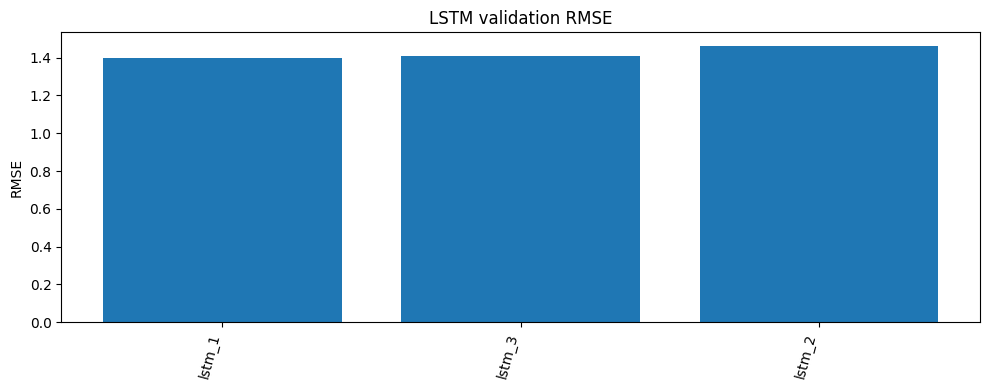

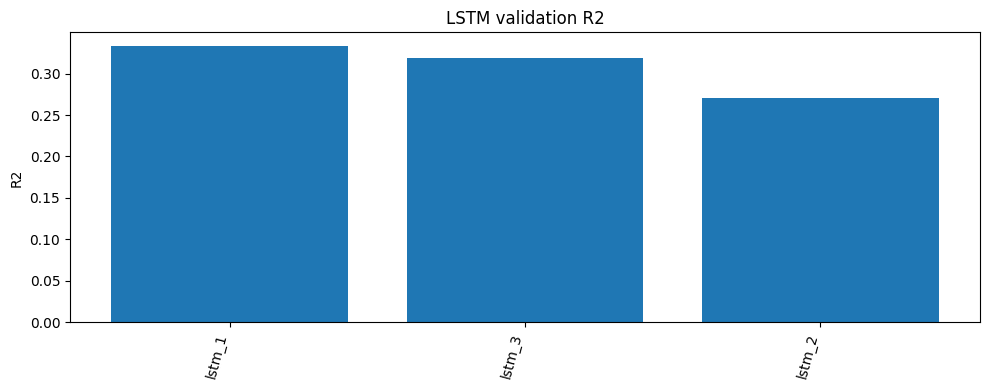

Best LSTM config: {'units': 32, 'dense_units': 16, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 128}


In [ ]:

lstm_results_df = pd.DataFrame(lstm_results).sort_values("rmse") if len(lstm_results) > 0 else pd.DataFrame()

if not lstm_results_df.empty:
    display(lstm_results_df)
    plot_metric_bars(lstm_results_df, "rmse", "LSTM validation RMSE")
    plot_metric_bars(lstm_results_df, "r2", "LSTM validation R2")
    print("Best LSTM config:", best_lstm_cfg)
else:
    print("No LSTM configurations produced usable sequences.")


In [ ]:

if best_lstm_model is not None and X_test_seq.shape[0] > 0:
    y_pred_lstm = best_lstm_model.predict(X_test_seq, verbose=0).flatten()
    lstm_test_row = metric_row("lstm_best", "test", y_test_seq, y_pred_lstm)
    test_rows.append(lstm_test_row)
    best_models["lstm"] = best_lstm_model
    model_predictions["lstm"] = y_pred_lstm
    display(pd.DataFrame([lstm_test_row]))
else:
    print("Best LSTM model not available or no usable test sequences.")


,model,split,rmse,mae,r2,n
0,lstm_best,test,2.464783,1.300943,0.224693,312


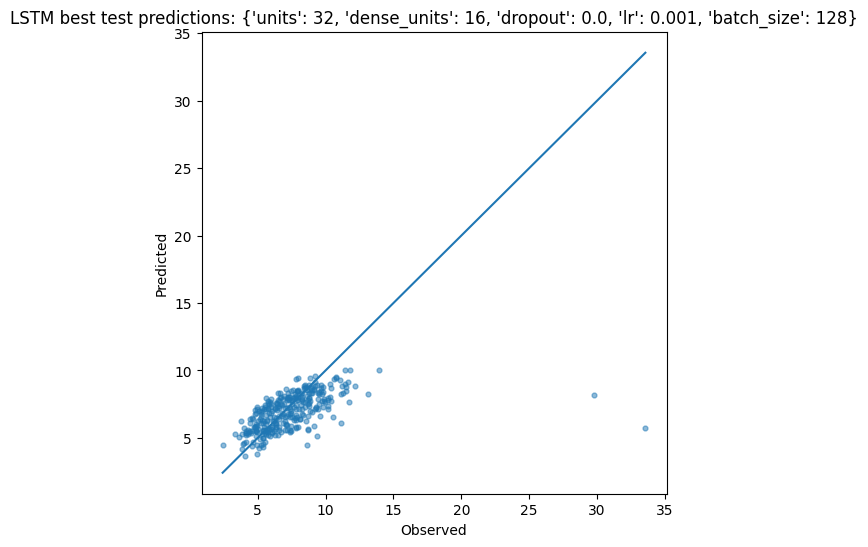

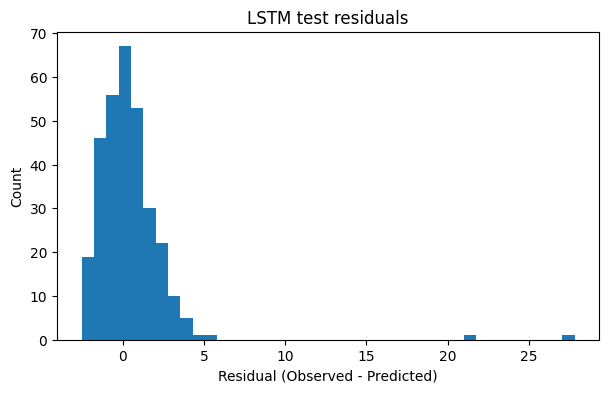

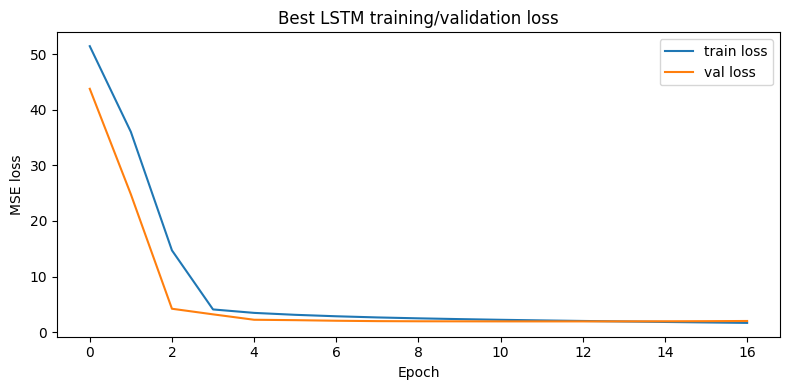

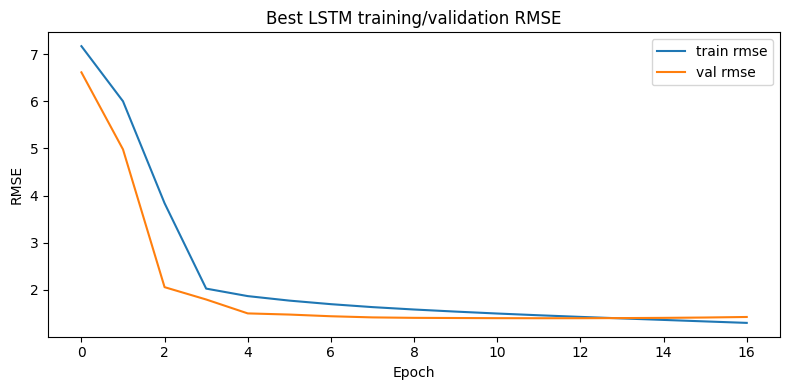

In [ ]:

if best_lstm_model is not None and X_test_seq.shape[0] > 0:
    plot_prediction_scatter(y_test_seq, y_pred_lstm, f"LSTM best test predictions: {best_lstm_cfg}")
    plot_residuals(y_test_seq, y_pred_lstm, "LSTM test residuals")

    plt.figure(figsize=(8, 4))
    plt.plot(best_lstm_history["loss"], label="train loss")
    plt.plot(best_lstm_history["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title("Best LSTM training/validation loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if "rmse" in best_lstm_history and "val_rmse" in best_lstm_history:
        plt.figure(figsize=(8, 4))
        plt.plot(best_lstm_history["rmse"], label="train rmse")
        plt.plot(best_lstm_history["val_rmse"], label="val rmse")
        plt.xlabel("Epoch")
        plt.ylabel("RMSE")
        plt.title("Best LSTM training/validation RMSE")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("Skipping LSTM diagnostic plots.")


In [ ]:

if best_lstm_model is not None and X_test_seq.shape[0] > 0:
    pd.DataFrame({
        "naps_id": meta_test_seq["naps_id"].values,
        "date": meta_test_seq["date"].values,
        "y_true": y_test_seq,
        "y_pred_lstm": y_pred_lstm
    }).to_csv(os.path.join(out_dir, "lstm_test_predictions.csv"), index=False)

    lstm_results_df.to_csv(os.path.join(out_dir, "lstm_validation_results.csv"), index=False)
    best_lstm_model.save(os.path.join(out_dir, "best_lstm.keras"))

    print("Saved LSTM outputs to:", out_dir)
else:
    print("No LSTM outputs saved because no model/test sequences were available.")


Saved LSTM outputs to: /content/drive/MyDrive/ML project data/Phase_3_data/model_comparison_outputs


## Final comparison

In [ ]:

validation_results_df = pd.DataFrame(validation_rows)
test_results_df = pd.DataFrame(test_rows).sort_values("rmse")

validation_results_df.to_csv(os.path.join(out_dir, "validation_results_all_candidates.csv"), index=False)
test_results_df.to_csv(os.path.join(out_dir, "test_results_best_models.csv"), index=False)

print("Validation candidates:", validation_results_df.shape)
print("Best models tested:", test_results_df.shape)

display(test_results_df)


Validation candidates: (24, 13)
Best models tested: (5, 6)


,model,split,rmse,mae,r2,n
4,lstm_best,test,2.464783,1.300943,0.224693,312
3,ffnn_best,test,3.662073,1.985392,0.133403,585
1,random_forest_best,test,3.665737,1.584041,0.131668,585
0,linear_family_best,test,3.699179,2.086642,0.115752,585
2,xgboost_best,test,3.839960,1.945341,0.047167,585


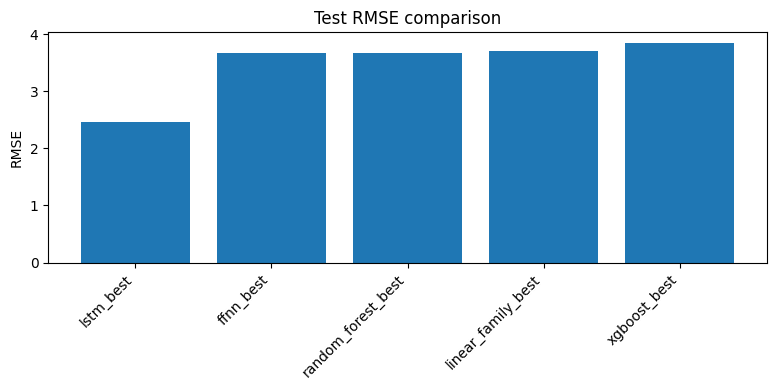

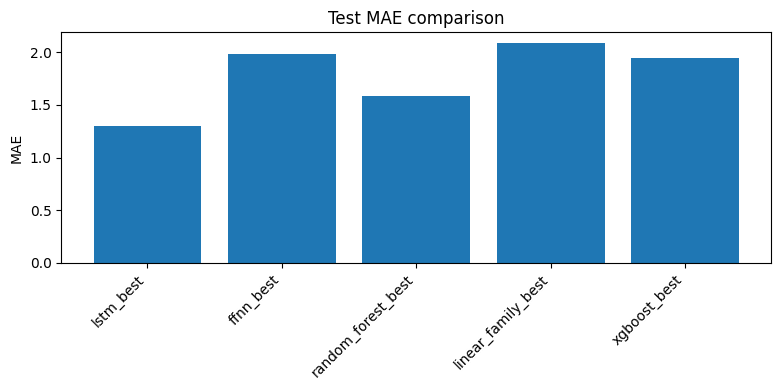

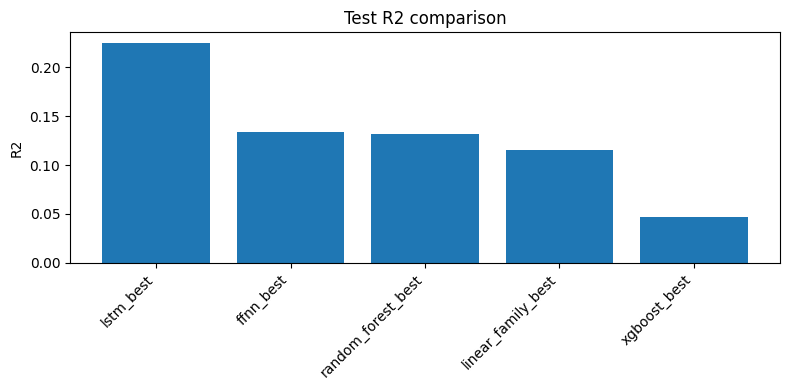

In [ ]:

plt.figure(figsize=(8, 4))
plt.bar(test_results_df["model"], test_results_df["rmse"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Test RMSE comparison")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(test_results_df["model"], test_results_df["mae"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("MAE")
plt.title("Test MAE comparison")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(test_results_df["model"], test_results_df["r2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R2")
plt.title("Test R2 comparison")
plt.tight_layout()
plt.show()


In [ ]:

# Save tabular-model test predictions in one file
pred_df = pd.DataFrame({"y_true": y_test})
if id_col is not None and id_col in test_df.columns:
    pred_df[id_col] = test_df[id_col].values
if date_col is not None and date_col in test_df.columns:
    pred_df[date_col] = test_df[date_col].values

for name, preds in model_predictions.items():
    if name != "lstm":
        pred_df[f"pred_{name}"] = preds

pred_df.to_csv(os.path.join(out_dir, "test_predictions_tabular_models.csv"), index=False)

summary = {
    "target_col": target_col,
    "n_features": len(feature_cols),
    "best_linear_model_file": "best_linear_family.joblib",
    "best_rf_model_file": "best_random_forest.joblib",
    "best_xgb_model_file": "best_xgboost.joblib",
    "best_ffnn_model_file": "best_ffnn.keras",
    "best_lstm_model_file": "best_lstm.keras" if "lstm" in best_models else None,
}

with open(os.path.join(out_dir, "run_summary.json"), "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("Saved outputs to:", out_dir)


Saved outputs to: /content/drive/MyDrive/ML project data/Phase_3_data/model_comparison_outputs


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error

# ------------------------------------------------------------
# "Accuracy" is not a standard regression metric.
# Here we define it as the proportion of predictions that are
# close enough to the true value.
#
# A prediction is counted as accurate if either:
#   |pred - true| <= ABS_TOL
# or
#   |pred - true| / max(|true|, 1e-8) <= REL_TOL
#
# You can change these thresholds.
# ------------------------------------------------------------
ABS_TOL = 2.0      # absolute tolerance, e.g. PM2.5 units
REL_TOL = 0.10     # relative tolerance, e.g. 10%

def regression_accuracy(y_true, y_pred, abs_tol=ABS_TOL, rel_tol=REL_TOL):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    abs_ok = np.abs(y_pred - y_true) <= abs_tol
    rel_ok = np.abs(y_pred - y_true) / np.maximum(np.abs(y_true), 1e-8) <= rel_tol

    return float(np.mean(abs_ok | rel_ok))

def prediction_bias(y_true, y_pred):
    return float(np.mean(np.asarray(y_pred) - np.asarray(y_true)))

def prediction_variance(y_pred):
    return float(np.var(np.asarray(y_pred), ddof=1)) if len(y_pred) > 1 else np.nan

def collect_regression_metrics(y_true, y_pred, model_name, split_name):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return {
        "model": model_name,
        "split": split_name,
        "accuracy": regression_accuracy(y_true, y_pred),
        "bias": prediction_bias(y_true, y_pred),
        "variance": prediction_variance(y_pred),
        "r2": float(r2_score(y_true, y_pred)),
        "mse": float(mean_squared_error(y_true, y_pred)),
        "n": int(len(y_true))
    }

In [ ]:
comparison_rows = []

# ------------------------------------------------------------
# Linear family
# ------------------------------------------------------------
if "linear_family" in best_models:
    pred_train = best_models["linear_family"].predict(X_train_scaled)
    pred_test = best_models["linear_family"].predict(X_test_scaled)

    comparison_rows.append(collect_regression_metrics(y_train, pred_train, "Linear_Family", "train"))
    comparison_rows.append(collect_regression_metrics(y_test, pred_test, "Linear_Family", "test"))

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------
if "random_forest" in best_models:
    pred_train = best_models["random_forest"].predict(X_train_imp)
    pred_test = best_models["random_forest"].predict(X_test_imp)

    comparison_rows.append(collect_regression_metrics(y_train, pred_train, "Random_Forest", "train"))
    comparison_rows.append(collect_regression_metrics(y_test, pred_test, "Random_Forest", "test"))

# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------
if "xgboost" in best_models:
    pred_train = best_models["xgboost"].predict(X_train_imp)
    pred_test = best_models["xgboost"].predict(X_test_imp)

    comparison_rows.append(collect_regression_metrics(y_train, pred_train, "XGBoost", "train"))
    comparison_rows.append(collect_regression_metrics(y_test, pred_test, "XGBoost", "test"))

# ------------------------------------------------------------
# MLP
# ------------------------------------------------------------
if "ffnn" in best_models:
    pred_train = best_models["ffnn"].predict(X_train_scaled)
    pred_test = best_models["ffnn"].predict(X_test_scaled)

    comparison_rows.append(collect_regression_metrics(y_train, pred_train, "ffnn", "train"))
    comparison_rows.append(collect_regression_metrics(y_test, pred_test, "ffnn", "test"))

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
# ------------------------------------------------------------
# LSTM
# ------------------------------------------------------------
if "best_lstm_model" in globals() and best_lstm_model is not None:
    if "X_train_seq" in globals() and len(X_train_seq) > 0:
        pred_train_seq = best_lstm_model.predict(X_train_seq, verbose=0).flatten()
        comparison_rows.append(collect_regression_metrics(y_train_seq, pred_train_seq, "LSTM", "train"))

    if "X_test_seq" in globals() and len(X_test_seq) > 0:
        pred_test_seq = best_lstm_model.predict(X_test_seq, verbose=0).flatten()
        comparison_rows.append(collect_regression_metrics(y_test_seq, pred_test_seq, "LSTM", "test"))

In [ ]:
metrics_compare_df = pd.DataFrame(comparison_rows)

# order columns
metrics_compare_df = metrics_compare_df[
    ["model", "split", "accuracy", "bias", "variance", "r2", "mse", "n"]
].sort_values(["split", "mse", "r2"], ascending=[True, True, False])

display(metrics_compare_df)

# optional save
metrics_compare_df.to_csv(
    "/content/drive/MyDrive/ML project data/Phase_3_data/model_comparison_outputs/regression_metrics_comparison_train_test.csv",
    index=False
)

,model,split,accuracy,bias,variance,r2,mse,n
9,LSTM,test,0.842949,-3.974797e-01,1.741304,0.224693,6.075156,312
7,ffnn,test,0.543113,-5.990047e-01,2.351863,0.133403,13.410782,585
3,Random_Forest,test,0.864957,-7.175933e-01,1.797924,0.131668,13.437630,585
1,Linear_Family,test,0.664957,-5.470138e-01,1.533388,0.115752,13.683925,585
5,XGBoost,test,0.747009,-1.021192e+00,0.819096,0.047167,14.745293,585
2,Random_Forest,train,0.998097,1.856420e-02,3.541665,0.952826,0.222217,2627
4,XGBoost,train,0.971450,-4.269260e-03,2.119853,0.827142,0.814269,2627
6,ffnn,train,0.548870,-2.218138e-01,2.416011,0.569984,2.025646,2627
8,LSTM,train,0.856198,3.778983e-03,1.691034,0.507800,2.060198,2267
0,Linear_Family,train,0.752569,9.737167e-17,1.447736,0.334991,3.132611,2627


In [ ]:
metrics_pivot_df = metrics_compare_df.pivot(index="model", columns="split", values=["accuracy", "bias", "variance", "r2", "mse"])
display(metrics_pivot_df)

accuracy                bias                variance            \
split              test     train      test         train      test     train   
model                                                                           
LSTM           0.842949  0.856198 -0.397480  3.778983e-03  1.741304  1.691034   
Linear_Family  0.664957  0.752569 -0.547014  9.737167e-17  1.533388  1.447736   
Random_Forest  0.864957  0.998097 -0.717593  1.856420e-02  1.797924  3.541665   
XGBoost        0.747009  0.971450 -1.021192 -4.269260e-03  0.819096  2.119853   
ffnn           0.543113  0.548870 -0.599005 -2.218138e-01  2.351863  2.416011   

                     r2                  mse            
split              test     train       test     train  
model                                                   
LSTM           0.224693  0.507800   6.075156  2.060198  
Linear_Family  0.115752  0.334991  13.683925  3.132611  
Random_Forest  0.131668  0.952826  13.437630  0.222217  
XGBoost        0.047167  0.827142  14.745293  0.814269  
ffnn           0.133403  0.569984  13.410782  2.025646

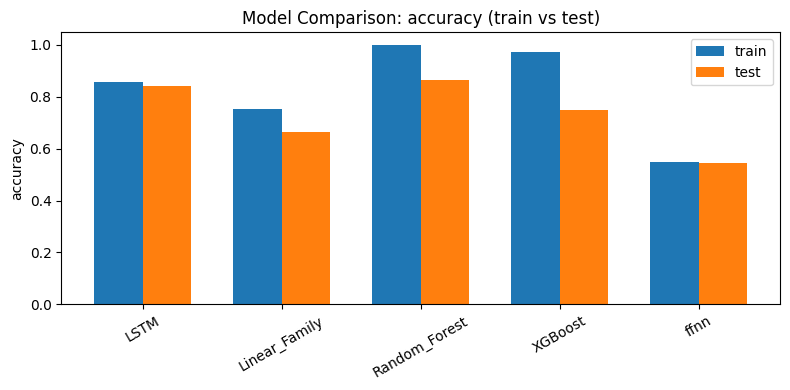

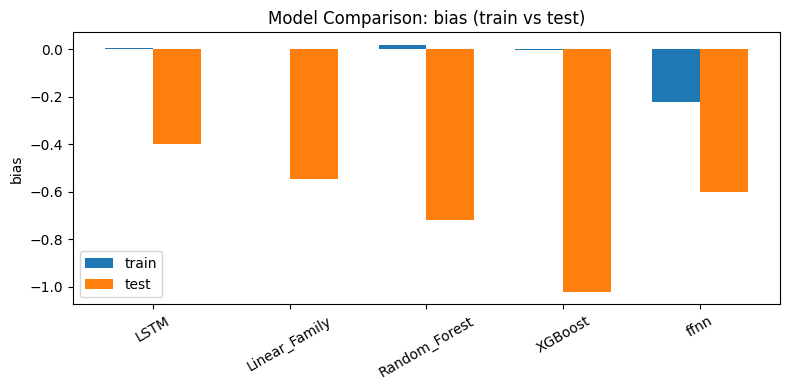

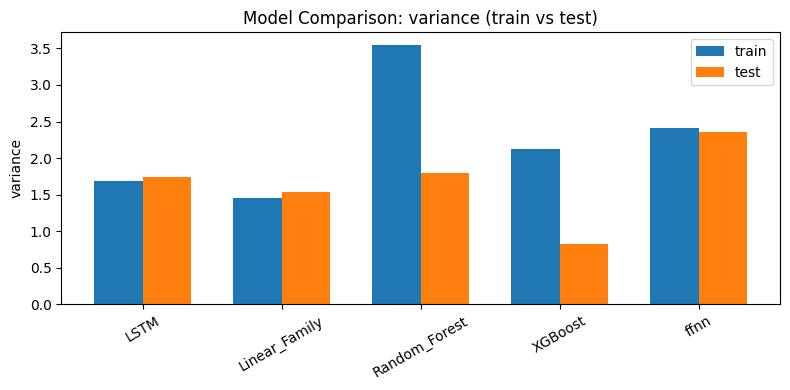

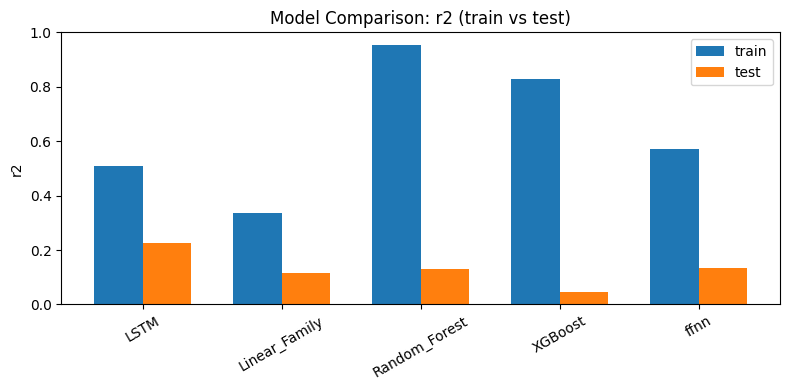

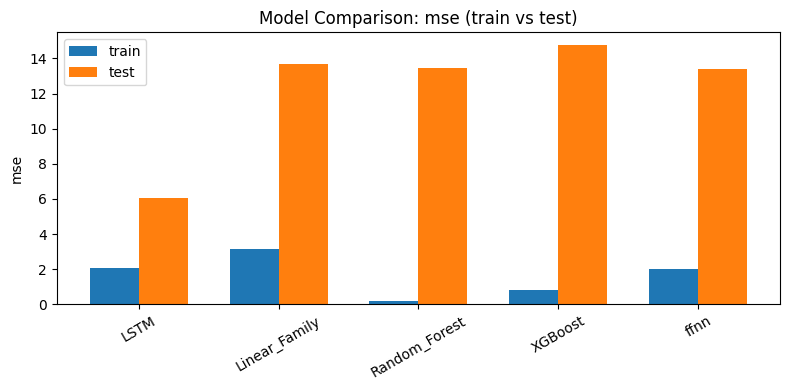

In [ ]:
plot_metrics = ["accuracy", "bias", "variance", "r2", "mse"]

for metric in plot_metrics:
    tmp = metrics_compare_df.pivot(index="model", columns="split", values=metric)

    # keep only models present
    tmp = tmp.copy()

    plt.figure(figsize=(8, 4))
    x = np.arange(len(tmp.index))
    width = 0.35

    train_vals = tmp["train"].values if "train" in tmp.columns else np.full(len(tmp.index), np.nan)
    test_vals = tmp["test"].values if "test" in tmp.columns else np.full(len(tmp.index), np.nan)

    plt.bar(x - width/2, train_vals, width, label="train")
    plt.bar(x + width/2, test_vals, width, label="test")

    plt.xticks(x, tmp.index, rotation=30)
    plt.ylabel(metric)
    plt.title(f"Model Comparison: {metric} (train vs test)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
gap_rows = []

for model_name in metrics_compare_df["model"].unique():
    sub = metrics_compare_df[metrics_compare_df["model"] == model_name].set_index("split")

    if {"train", "test"}.issubset(sub.index):
        gap_rows.append({
            "model": model_name,
            "accuracy_gap_test_minus_train": float(sub.loc["test", "accuracy"] - sub.loc["train", "accuracy"]),
            "bias_gap_test_minus_train": float(sub.loc["test", "bias"] - sub.loc["train", "bias"]),
            "variance_gap_test_minus_train": float(sub.loc["test", "variance"] - sub.loc["train", "variance"]),
            "r2_gap_test_minus_train": float(sub.loc["test", "r2"] - sub.loc["train", "r2"]),
            "mse_gap_test_minus_train": float(sub.loc["test", "mse"] - sub.loc["train", "mse"]),
        })

gap_df = pd.DataFrame(gap_rows).sort_values("mse_gap_test_minus_train", ascending=False)
display(gap_df)

gap_df.to_csv(
    "/content/drive/MyDrive/ML project data/Phase_3_data/model_comparison_outputs/regression_metric_gaps.csv",
    index=False
)

,model,accuracy_gap_test_minus_train,bias_gap_test_minus_train,variance_gap_test_minus_train,r2_gap_test_minus_train,mse_gap_test_minus_train
4,XGBoost,-0.224442,-1.016923,-1.300757,-0.779975,13.931024
2,Random_Forest,-0.133139,-0.736157,-1.743740,-0.821159,13.215413
1,ffnn,-0.005757,-0.377191,-0.064148,-0.436581,11.385135
3,Linear_Family,-0.087612,-0.547014,0.085652,-0.219238,10.551314
0,LSTM,-0.013249,-0.401259,0.050271,-0.283107,4.014958


In [ ]:
test_only = metrics_compare_df[metrics_compare_df["split"] == "test"].copy()

test_only["abs_bias"] = test_only["bias"].abs()

test_only["rank_accuracy"] = test_only["accuracy"].rank(ascending=False, method="min")
test_only["rank_abs_bias"] = test_only["abs_bias"].rank(ascending=True, method="min")
test_only["rank_variance"] = test_only["variance"].rank(ascending=True, method="min")
test_only["rank_r2"] = test_only["r2"].rank(ascending=False, method="min")
test_only["rank_mse"] = test_only["mse"].rank(ascending=True, method="min")

test_only["rank_total"] = (
    test_only["rank_accuracy"] +
    test_only["rank_abs_bias"] +
    test_only["rank_variance"] +
    test_only["rank_r2"] +
    test_only["rank_mse"]
)

test_ranking_df = test_only.sort_values("rank_total")

display(
    test_ranking_df[
        ["model", "accuracy", "bias", "variance", "r2", "mse",
         "rank_accuracy", "rank_abs_bias", "rank_variance", "rank_r2", "rank_mse", "rank_total"]
    ]
)

test_ranking_df.to_csv(
    "/content/drive/MyDrive/ML project data/Phase_3_data/model_comparison_outputs/regression_metric_ranking_test.csv",
    index=False
)

,model,accuracy,bias,variance,r2,mse,rank_accuracy,rank_abs_bias,rank_variance,rank_r2,rank_mse,rank_total
9,LSTM,0.842949,-0.397480,1.741304,0.224693,6.075156,2.0,1.0,3.0,1.0,1.0,8.0
3,Random_Forest,0.864957,-0.717593,1.797924,0.131668,13.437630,1.0,4.0,4.0,3.0,3.0,15.0
1,Linear_Family,0.664957,-0.547014,1.533388,0.115752,13.683925,4.0,2.0,2.0,4.0,4.0,16.0
7,ffnn,0.543113,-0.599005,2.351863,0.133403,13.410782,5.0,3.0,5.0,2.0,2.0,17.0
5,XGBoost,0.747009,-1.021192,0.819096,0.047167,14.745293,3.0,5.0,1.0,5.0,5.0,19.0


In [ ]:
!pip -q install shap

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

In [ ]:
lstm_shap_out_dir = "/content/drive/MyDrive/ML project data/Phase_3_data/model_comparison_outputs/lstm_shap"
os.makedirs(lstm_shap_out_dir, exist_ok=True)

# keep runtime manageable
MAX_BG_SEQ = 40
MAX_EXP_SEQ = 40
NSAMPLES_KERNEL = 80

print("LSTM SHAP output folder:", lstm_shap_out_dir)

LSTM SHAP output folder: /content/drive/MyDrive/ML project data/Phase_3_data/model_comparison_outputs/lstm_shap


In [ ]:
def sample_array_rows(arr, max_rows=40, random_state=42):
    arr = np.asarray(arr)
    if len(arr) <= max_rows:
        return arr.copy()
    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(arr), size=max_rows, replace=False)
    return arr[idx].copy()

def flatten_sequence_array(X_seq, feature_names, seq_len):
    X_seq = np.asarray(X_seq)
    n, t, f = X_seq.shape
    flat = X_seq.reshape(n, t * f)

    colnames = []
    for step in range(seq_len):
        lag_num = seq_len - step
        for feat in feature_names:
            colnames.append(f"t-{lag_num}_{feat}")

    return pd.DataFrame(flat, columns=colnames)

def lstm_predict_from_flat(x_flat, model, seq_len, n_features):
    x_flat = np.asarray(x_flat, dtype=np.float32)
    x_3d = x_flat.reshape(len(x_flat), seq_len, n_features)
    preds = model.predict(x_3d, verbose=0).flatten()
    return preds

def save_shap_importance_csv(shap_values, feature_names, out_path):
    arr = np.abs(np.asarray(shap_values))
    mean_abs = arr.mean(axis=0)

    imp_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs
    }).sort_values("mean_abs_shap", ascending=False)

    imp_df.to_csv(out_path, index=False)
    return imp_df

def collapse_lstm_shap_by_base_feature(shap_values, flat_feature_names):
    arr = np.abs(np.asarray(shap_values))
    imp_df = pd.DataFrame({
        "feature": flat_feature_names,
        "mean_abs_shap": arr.mean(axis=0)
    })

    # remove the timestep prefix, e.g. t-12_air_sfc_mean -> air_sfc_mean
    imp_df["base_feature"] = imp_df["feature"].str.replace(r"^t-\d+_", "", regex=True)

    collapsed = (
        imp_df.groupby("base_feature", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
    )
    return collapsed

def collapse_lstm_shap_by_timestep(shap_values, flat_feature_names):
    arr = np.abs(np.asarray(shap_values))
    imp_df = pd.DataFrame({
        "feature": flat_feature_names,
        "mean_abs_shap": arr.mean(axis=0)
    })

    imp_df["timestep"] = imp_df["feature"].str.extract(r"^(t-\d+)_")[0]

    collapsed = (
        imp_df.groupby("timestep", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("timestep")
    )
    return collapsed

In [ ]:
if best_lstm_model is None:
    raise ValueError("best_lstm_model is None. Train the LSTM first.")

if len(X_train_seq) == 0 or len(X_test_seq) == 0:
    raise ValueError("X_train_seq or X_test_seq is empty. Build LSTM sequences first.")

X_bg_seq = sample_array_rows(X_train_seq, max_rows=MAX_BG_SEQ, random_state=42)
X_exp_seq = sample_array_rows(X_test_seq, max_rows=MAX_EXP_SEQ, random_state=42)

X_bg_flat = flatten_sequence_array(X_bg_seq, feature_cols_lstm, seq_len)
X_exp_flat = flatten_sequence_array(X_exp_seq, feature_cols_lstm, seq_len)

print("Background flat shape:", X_bg_flat.shape)
print("Explain flat shape:", X_exp_flat.shape)

display(X_exp_flat.head())

Background flat shape: (40, 456)
Explain flat shape: (40, 456)


,t-12_acpcp_max,t-12_acpcp_mean,t-12_air_sfc_max,t-12_air_sfc_mean,t-12_albedo_max,t-12_albedo_mean,t-12_dswrf_max,t-12_dswrf_mean,t-12_evap_max,t-12_evap_mean,t-12_hcdc_max,t-12_hcdc_mean,t-12_hpbl_max,t-12_hpbl_mean,t-12_lcdc_max,t-12_lcdc_mean,t-12_mcdc_max,t-12_mcdc_mean,t-12_pr_wtr_max,t-12_pr_wtr_mean,t-12_pres_sfc_max,t-12_pres_sfc_mean,t-12_shum_2m_max,t-12_shum_2m_mean,t-12_uwnd_10m_max,t-12_uwnd_10m_mean,t-12_vis_max,t-12_vis_mean,t-12_vwnd_10m_max,t-12_vwnd_10m_mean,t-12_sat_est,t-12_ndvi,t-12_elev_m,t-12_road_weighted_km_per_km2,t-12_landcover,t-12_pm25_lag1,t-12_pm25_lag2,t-12_pm25_lag3,t-11_acpcp_max,t-11_acpcp_mean,t-11_air_sfc_max,t-11_air_sfc_mean,t-11_albedo_max,t-11_albedo_mean,t-11_dswrf_max,t-11_dswrf_mean,t-11_evap_max,t-11_evap_mean,t-11_hcdc_max,t-11_hcdc_mean,t-11_hpbl_max,t-11_hpbl_mean,t-11_lcdc_max,t-11_lcdc_mean,t-11_mcdc_max,t-11_mcdc_mean,t-11_pr_wtr_max,t-11_pr_wtr_mean,t-11_pres_sfc_max,t-11_pres_sfc_mean,t-11_shum_2m_max,t-11_shum_2m_mean,t-11_uwnd_10m_max,t-11_uwnd_10m_mean,t-11_vis_max,t-11_vis_mean,t-11_vwnd_10m_max,t-11_vwnd_10m_mean,t-11_sat_est,t-11_ndvi,t-11_elev_m,t-11_road_weighted_km_per_km2,t-11_landcover,t-11_pm25_lag1,t-11_pm25_lag2,t-11_pm25_lag3,t-10_acpcp_max,t-10_acpcp_mean,t-10_air_sfc_max,t-10_air_sfc_mean,t-10_albedo_max,t-10_albedo_mean,t-10_dswrf_max,t-10_dswrf_mean,t-10_evap_max,t-10_evap_mean,t-10_hcdc_max,t-10_hcdc_mean,t-10_hpbl_max,t-10_hpbl_mean,t-10_lcdc_max,t-10_lcdc_mean,t-10_mcdc_max,t-10_mcdc_mean,t-10_pr_wtr_max,t-10_pr_wtr_mean,t-10_pres_sfc_max,t-10_pres_sfc_mean,t-10_shum_2m_max,t-10_shum_2m_mean,...,t-3_lcdc_max,t-3_lcdc_mean,t-3_mcdc_max,t-3_mcdc_mean,t-3_pr_wtr_max,t-3_pr_wtr_mean,t-3_pres_sfc_max,t-3_pres_sfc_mean,t-3_shum_2m_max,t-3_shum_2m_mean,t-3_uwnd_10m_max,t-3_uwnd_10m_mean,t-3_vis_max,t-3_vis_mean,t-3_vwnd_10m_max,t-3_vwnd_10m_mean,t-3_sat_est,t-3_ndvi,t-3_elev_m,t-3_road_weighted_km_per_km2,t-3_landcover,t-3_pm25_lag1,t-3_pm25_lag2,t-3_pm25_lag3,t-2_acpcp_max,t-2_acpcp_mean,t-2_air_sfc_max,t-2_air_sfc_mean,t-2_albedo_max,t-2_albedo_mean,t-2_dswrf_max,t-2_dswrf_mean,t-2_evap_max,t-2_evap_mean,t-2_hcdc_max,t-2_hcdc_mean,t-2_hpbl_max,t-2_hpbl_mean,t-2_lcdc_max,t-2_lcdc_mean,t-2_mcdc_max,t-2_mcdc_mean,t-2_pr_wtr_max,t-2_pr_wtr_mean,t-2_pres_sfc_max,t-2_pres_sfc_mean,t-2_shum_2m_max,t-2_shum_2m_mean,t-2_uwnd_10m_max,t-2_uwnd_10m_mean,t-2_vis_max,t-2_vis_mean,t-2_vwnd_10m_max,t-2_vwnd_10m_mean,t-2_sat_est,t-2_ndvi,t-2_elev_m,t-2_road_weighted_km_per_km2,t-2_landcover,t-2_pm25_lag1,t-2_pm25_lag2,t-2_pm25_lag3,t-1_acpcp_max,t-1_acpcp_mean,t-1_air_sfc_max,t-1_air_sfc_mean,t-1_albedo_max,t-1_albedo_mean,t-1_dswrf_max,t-1_dswrf_mean,t-1_evap_max,t-1_evap_mean,t-1_hcdc_max,t-1_hcdc_mean,t-1_hpbl_max,t-1_hpbl_mean,t-1_lcdc_max,t-1_lcdc_mean,t-1_mcdc_max,t-1_mcdc_mean,t-1_pr_wtr_max,t-1_pr_wtr_mean,t-1_pres_sfc_max,t-1_pres_sfc_mean,t-1_shum_2m_max,t-1_shum_2m_mean,t-1_uwnd_10m_max,t-1_uwnd_10m_mean,t-1_vis_max,t-1_vis_mean,t-1_vwnd_10m_max,t-1_vwnd_10m_mean,t-1_sat_est,t-1_ndvi,t-1_elev_m,t-1_road_weighted_km_per_km2,t-1_landcover,t-1_pm25_lag1,t-1_pm25_lag2,t-1_pm25_lag3
0,0.547934,1.099003,1.254459,1.432397,-0.579435,-0.288238,1.160850,1.597764,1.054770,2.540662,-1.521651,-1.196973,-2.446106,-1.294464,-2.599641,-1.494053,-2.750840,-1.828644,1.601168,1.558905,-0.513391,-0.017577,1.731580,2.079106,-1.585766,-0.418484,0.142805,0.956364,-1.170922,-0.657003,0.438047,0.074299,0.189144,-0.253311,0.276801,0.332962,-0.660012,-0.534173,1.186829,2.370872,0.919153,1.217062,-0.579435,-0.288238,0.860500,0.930827,0.653334,1.297803,0.692285,-0.405754,-0.903231,-0.758859,-2.216517,-1.259601,-0.358252,-0.909901,1.184330,1.217662,-0.171561,0.095103,1.175971,1.489395,-0.451337,-0.179116,0.132879,0.771486,0.017045,0.236264,0.714688,-0.172178,0.189144,-0.253311,0.276801,0.098619,0.331545,-0.665411,0.530637,0.491963,0.940129,1.052258,-0.579435,-0.288238,0.282664,0.584388,-0.348461,0.006413,-0.391460,-1.154441,-2.041384,-1.505044,-3.168853,-1.801650,-2.255079,-1.684406,0.820221,

In [ ]:
lstm_predict_fn = lambda x: lstm_predict_from_flat(
    x,
    best_lstm_model,
    seq_len=seq_len,
    n_features=len(feature_cols_lstm)
)

lstm_explainer = shap.KernelExplainer(lstm_predict_fn, X_bg_flat)
lstm_shap_values = lstm_explainer.shap_values(X_exp_flat, nsamples=NSAMPLES_KERNEL)

lstm_shap_values = np.asarray(lstm_shap_values)
print("LSTM SHAP values shape:", lstm_shap_values.shape)

  0%|          | 0/40 [00:00<?, ?it/s]

LSTM SHAP values shape: (40, 456)


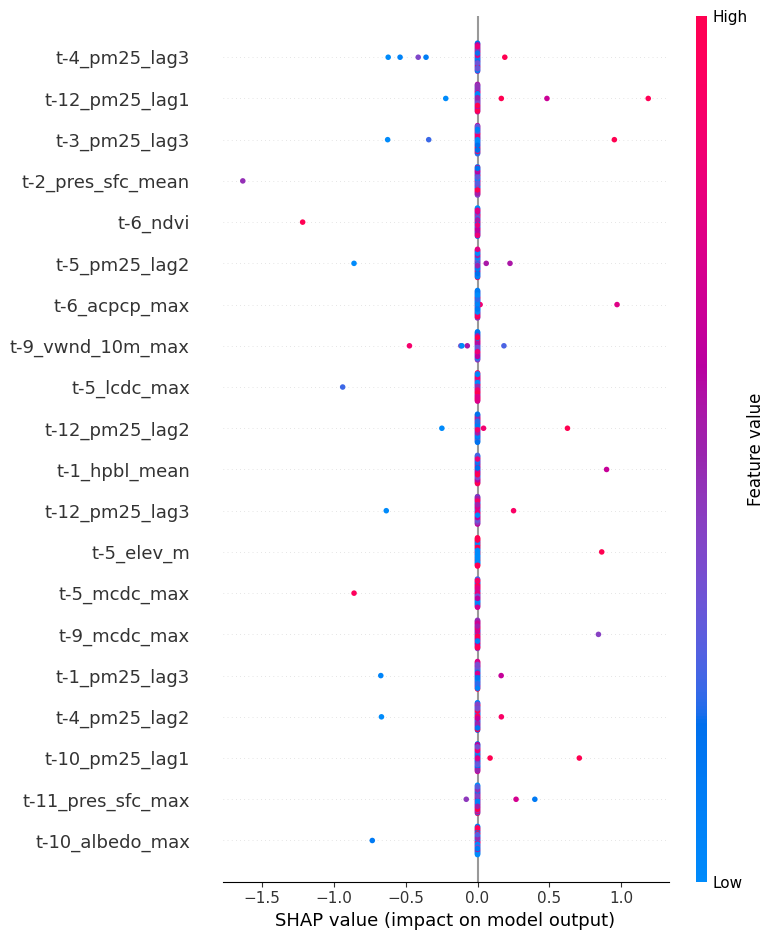

In [ ]:
plt.figure()
shap.summary_plot(lstm_shap_values, X_exp_flat, show=False)
plt.tight_layout()
plt.savefig(os.path.join(lstm_shap_out_dir, "lstm_shap_summary.png"), dpi=220, bbox_inches="tight")
plt.show()

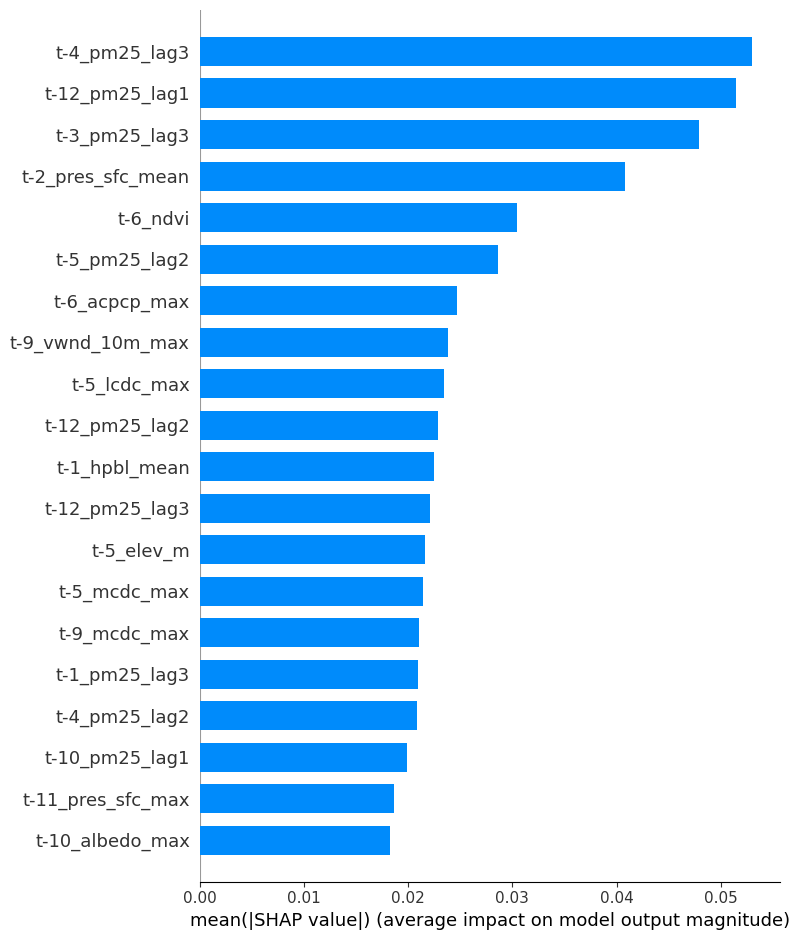

In [ ]:
plt.figure()
shap.summary_plot(lstm_shap_values, X_exp_flat, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(os.path.join(lstm_shap_out_dir, "lstm_shap_bar.png"), dpi=220, bbox_inches="tight")
plt.show()

In [ ]:
lstm_imp_df = save_shap_importance_csv(
    lstm_shap_values,
    X_exp_flat.columns.tolist(),
    os.path.join(lstm_shap_out_dir, "lstm_shap_importance_by_timestep_feature.csv")
)

display(lstm_imp_df.head(25))

,feature,mean_abs_shap
341,t-4_pm25_lag3,0.053017
35,t-12_pm25_lag1,0.051423
379,t-3_pm25_lag3,0.047914
401,t-2_pres_sfc_mean,0.040820
259,t-6_ndvi,0.030411
302,t-5_pm25_lag2,0.028641
228,t-6_acpcp_max,0.024711
142,t-9_vwnd_10m_max,0.023822
280,t-5_lcdc_max,0.023450
36,t-12_pm25_lag2,0.022887


In [ ]:
lstm_base_feature_imp = collapse_lstm_shap_by_base_feature(
    lstm_shap_values,
    X_exp_flat.columns.tolist()
)

lstm_base_feature_imp.to_csv(
    os.path.join(lstm_shap_out_dir, "lstm_shap_importance_by_base_feature.csv"),
    index=False
)

display(lstm_base_feature_imp.head(20))

,base_feature,mean_abs_shap
23,pm25_lag3,0.173549
21,pm25_lag1,0.114956
22,pm25_lag2,0.114626
8,elev_m,0.081569
27,pres_sfc_mean,0.068870
0,acpcp_max,0.068169
18,mcdc_max,0.067218
7,dswrf_mean,0.064918
5,albedo_mean,0.060043
16,lcdc_max,0.053900


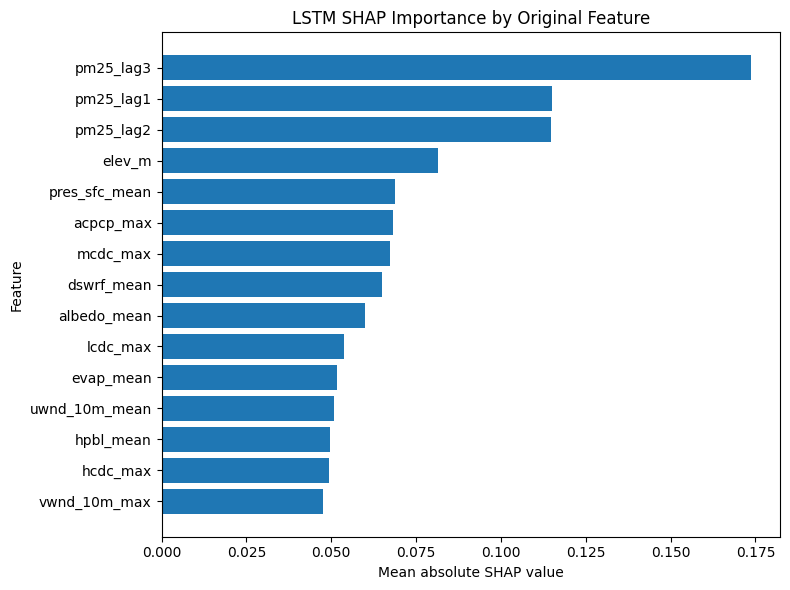

In [ ]:
top_n = 15
plot_df = lstm_base_feature_imp.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(plot_df["base_feature"], plot_df["mean_abs_shap"])
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.title("LSTM SHAP Importance by Original Feature")
plt.tight_layout()
plt.savefig(os.path.join(lstm_shap_out_dir, "lstm_top_base_features.png"), dpi=220, bbox_inches="tight")
plt.show()

In [ ]:
lstm_timestep_imp = collapse_lstm_shap_by_timestep(
    lstm_shap_values,
    X_exp_flat.columns.tolist()
)

lstm_timestep_imp.to_csv(
    os.path.join(lstm_shap_out_dir, "lstm_shap_importance_by_timestep.csv"),
    index=False
)

display(lstm_timestep_imp)

,timestep,mean_abs_shap
0,t-1,0.121425
1,t-10,0.110500
2,t-11,0.187538
3,t-12,0.180105
4,t-2,0.127507
5,t-3,0.138122
6,t-4,0.194880
7,t-5,0.183906
8,t-6,0.153102
9,t-7,0.137058


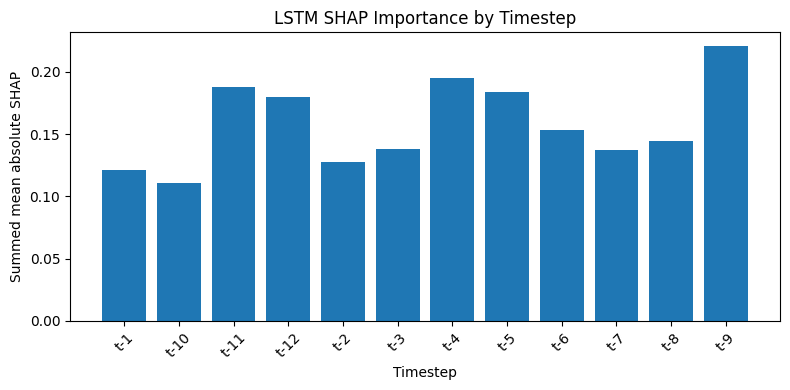

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(lstm_timestep_imp["timestep"], lstm_timestep_imp["mean_abs_shap"])
plt.xlabel("Timestep")
plt.ylabel("Summed mean absolute SHAP")
plt.title("LSTM SHAP Importance by Timestep")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(lstm_shap_out_dir, "lstm_shap_by_timestep.png"), dpi=220, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

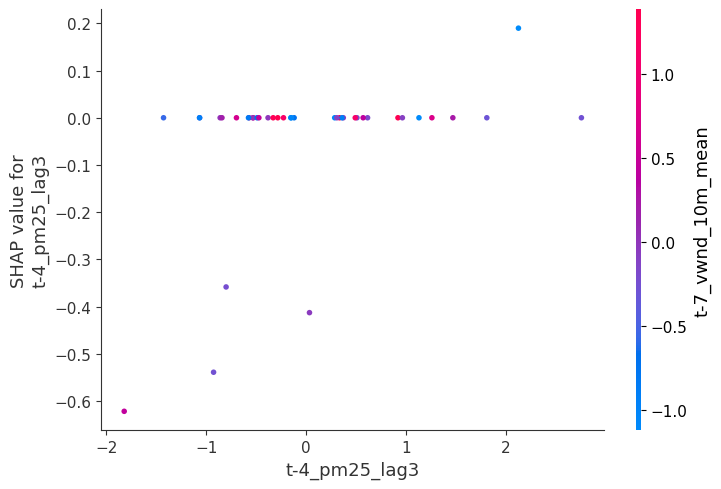

<Figure size 640x480 with 0 Axes>

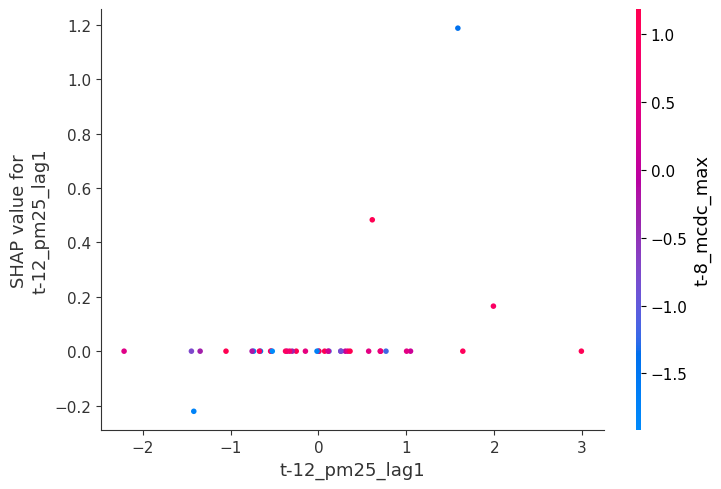

<Figure size 640x480 with 0 Axes>

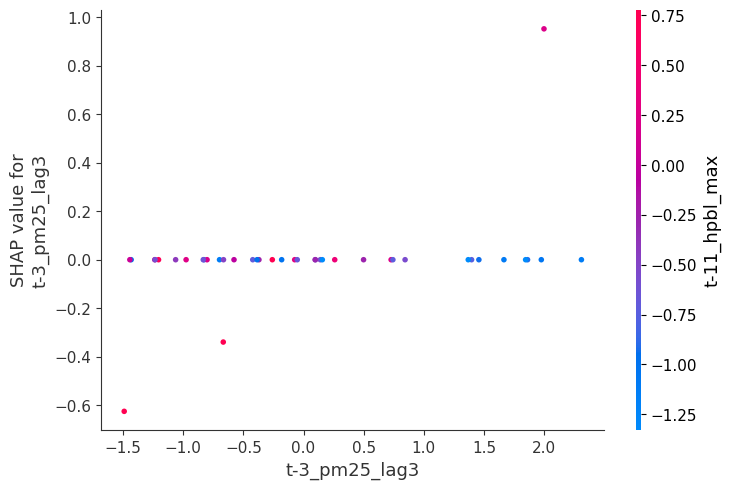

<Figure size 640x480 with 0 Axes>

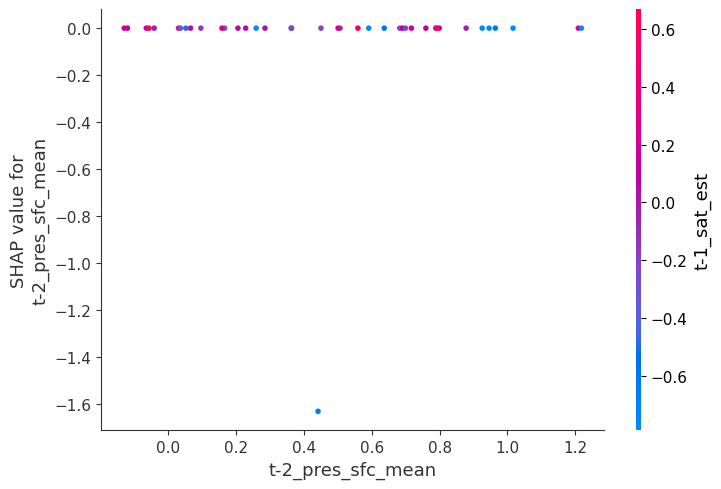

<Figure size 640x480 with 0 Axes>

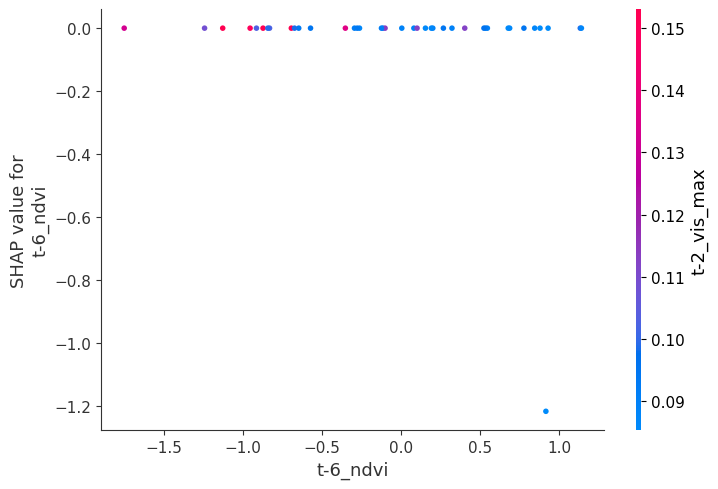

In [ ]:
top_flat_features = lstm_imp_df["feature"].head(5).tolist()

for feat in top_flat_features:
    try:
        plt.figure()
        shap.dependence_plot(feat, lstm_shap_values, X_exp_flat, show=False)
        plt.tight_layout()
        plt.savefig(
            os.path.join(lstm_shap_out_dir, f"dependence_{feat}.png"),
            dpi=220,
            bbox_inches="tight"
        )
        plt.show()
    except Exception as e:
        print(f"Skipped dependence plot for {feat}: {e}")